# Spotify Listening History Exploratory Data Analysis (EDA) and Visualization



## Introduction
The data used for EDA will be from my Spotify Listening History Dataset, a compilation of information about every stream from my personal Spotify account since I first registered back in 2017.  In this section of the project I will perform tasks to clean and explore the contents of the dataset, planning for how to approach visualization of meaningful insights.

In [64]:
# Notebook setup
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from scipy.stats import chi2_contingency
from statsmodels.stats.proportion import proportions_ztest
import scipy.stats as stats

## Examining the Data

In [65]:
# Read in the Spotify Listening History Dataset
spotify = pd.read_csv('../data/processed/spotify_data_with_hybrid_genres.csv', low_memory= False)
spotify.head()

,ts,platform,ms_played,conn_country,ip_addr,master_metadata_track_name,master_metadata_album_artist_name,master_metadata_album_album_name,spotify_track_uri,episode_name,...,audiobook_chapter_title,reason_start,reason_end,shuffle,skipped,offline,offline_timestamp,incognito_mode,genre,genre_method
0,2022-11-23 15:36:09+00:00,ios,177226,US,148.59.24.104,RUNNING OUT OF TIME,"Tyler, The Creator",IGOR,spotify:track:5QvBXUm5MglLJ3iBfTX2Wo,NaN,...,NaN,trackdone,trackdone,False,False,False,1.669218e+09,False,hip hop,musicbrainz_fallback
1,2022-11-23 15:37:17+00:00,ios,67638,US,148.59.24.104,Attracted to You,PinkPantheress,Attracted To You,spotify:track:4fPjI40ElIwJQ4DJJxSCOe,NaN,...,NaN,trackdone,trackdone,False,False,False,1.669218e+09,False,bedroom pop,spotify
2,2022-11-23 15:40:26+00:00,ios,188658,US,148.59.24.104,Matinee,Smino,Luv 4 Rent,spotify:track:3EFRMoIReL2DU56ltcPRTV,NaN,...,NaN,trackdone,trackdone,False,False,False,1.669218e+09,False,"r&b, soul, electronic, hip hop",manual_correction
3,2022-11-23 15:42:17+00:00,ios,109818,US,148.59.24.104,Basement Jack,Steve Lacy,Apollo XXI,spotify:track:3NOIkyNWG0fEjkPkq9HVMW,NaN,...,NaN,trackdone,trackdone,False,False,False,1.669218e+09,False,"free jazz, avant-garde, hard bop, jazz",spotify
4,2022-11-23 15:44:27+00:00,ios,129553,US,148.59.24.104,Soulfood,redveil,Soulfood,spotify:track:2uL3sat19TiMOOahR2jutD,NaN,...,NaN,trackdone,trackdone,False,False,False,1.669218e+09,False,"alternative hip hop, experimental hip hop, und...",spotify


Let's reorder this dataset so that it is in chronological order, as the first row is from 2022, but the data goes back to 2017.

In [66]:
spotify = spotify.sort_values('ts', ascending= True)
spotify.head()

,ts,platform,ms_played,conn_country,ip_addr,master_metadata_track_name,master_metadata_album_artist_name,master_metadata_album_album_name,spotify_track_uri,episode_name,...,audiobook_chapter_title,reason_start,reason_end,shuffle,skipped,offline,offline_timestamp,incognito_mode,genre,genre_method
63588,2017-03-21 01:29:19+00:00,"iOS 10.2.1 (iPhone7,2)",2066,US,76.187.74.226,Little Debbie,Mr_hotspot,Little Debbie,spotify:track:3JZgepLdsIj3s5o7kmsmAS,NaN,...,NaN,playbtn,fwdbtn,True,False,False,NaN,False,Unknown,both_failed
63589,2017-03-21 01:30:00+00:00,"iOS 10.2.1 (iPhone7,2)",11075,US,76.187.74.226,Steal Her Man (feat. Trinity Taylor),Taylor Girlz,Steal Her Man (feat. Trinity Taylor),spotify:track:2YnZVGFZL9xf3TQIyOvSYQ,NaN,...,NaN,fwdbtn,logout,True,False,False,NaN,False,lullaby,spotify
63590,2017-03-21 01:34:32+00:00,"iOS 10.2.1 (iPhone7,2)",23173,US,76.187.74.226,"Tonight, Tonight, Tonight - Live",Genesis,"The Way We Walk, Vol. 1: The Shorts (Live)",spotify:track:5uklWXZwYam1coDJRA4w8g,NaN,...,NaN,playbtn,endplay,True,False,False,NaN,False,"progressive rock, art rock",cached_spotify
63591,2017-03-21 01:34:44+00:00,"iOS 10.2.1 (iPhone7,2)",11470,US,76.187.74.226,Anything She Does - 2007 Remaster,Genesis,Invisible Touch,spotify:track:2canQc7nVIxdRbZp5r3VHo,NaN,...,NaN,playbtn,fwdbtn,True,False,False,NaN,False,"progressive rock, art rock",cached_spotify
63592,2017-03-21 01:34:45+00:00,"iOS 10.2.1 (iPhone7,2)",766,US,76.187.74.226,Minnesota,Lil Yachty,Lil Boat,spotify:track:4XkOcWt0C2JX1s2RXybosk,NaN,...,NaN,fwdbtn,fwdbtn,True,False,False,NaN,False,hip hop,manual_correction


At a glance, we can see that each observation represents one stream from my personal Spotify account at its exact time.

Let's define some of the basic information of this dataset.

In [67]:
spotify.describe(include='all')

,ts,platform,ms_played,conn_country,ip_addr,master_metadata_track_name,master_metadata_album_artist_name,master_metadata_album_album_name,spotify_track_uri,episode_name,...,audiobook_chapter_title,reason_start,reason_end,shuffle,skipped,offline,offline_timestamp,incognito_mode,genre,genre_method
count,226394,226394,2.263940e+05,226394,226394,226181,226181,226181,226181,211,...,0.0,226394,226394,226394,226394,226359,1.305470e+05,226394,226394,226394
unique,221304,66,NaN,12,7175,14742,4538,8916,16909,73,...,NaN,10,12,2,2,2,NaN,2,1815,7
top,2022-07-30 19:03:02+00:00,ios,NaN,US,99.139.148.200,Static,Steve Lacy,Gemini Rights,spotify:track:4OmfWzukSVD140NiAIEjem,"10hrs of Gentle Rain with Thunder, Rain Sounds...",...,NaN,trackdone,trackdone,True,False,False,NaN,False,Unknown,cached_spotify
freq,67,114814,NaN,224323,54494,617,4217,1809,615,33,...,NaN,119311,121751,134955,173879,224587,NaN,226009,35361,148468
mean,NaN,NaN,1.258740e+05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,7.406590e+09,NaN,NaN,NaN
std,NaN,NaN,2.408990e+05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,9.537708e+10,NaN,NaN,NaN
min,NaN,NaN,0.000000e+00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,1.665784e+09,NaN,NaN,NaN
25%,NaN,NaN,1.550525e+04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,1.695927e+09,NaN,NaN,NaN
50%,NaN,NaN,1.268570e+05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,1.715148e+09,NaN,NaN,NaN
75%,NaN,NaN,1.920778e+05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,1.732118e+09,NaN,NaN,NaN


In [68]:
print("=== DATASET BASIC INFO ===")
print(f"Dataset shape: {spotify.shape}")
print(f"Number of tracks: {len(spotify)}")
print(f"Number of features: {spotify.shape[1]}")

=== DATASET BASIC INFO ===
Dataset shape: (226394, 25)
Number of tracks: 226394
Number of features: 25


Although the number of features is 25, quite a few of these features correspond to information relating to podcast and audiobook streaming (which I don't do a lot of at all), causing there to be a lot of NaN values for those features, but this is expected.

Let's take a look at the features of the data and their data types.

In [69]:
print("\n=== COLUMN NAMES AND DATA TYPES ===")
print(spotify.dtypes)


=== COLUMN NAMES AND DATA TYPES ===
ts                                    object
platform                              object
ms_played                              int64
conn_country                          object
ip_addr                               object
master_metadata_track_name            object
master_metadata_album_artist_name     object
master_metadata_album_album_name      object
spotify_track_uri                     object
episode_name                          object
episode_show_name                     object
spotify_episode_uri                   object
audiobook_title                      float64
audiobook_uri                        float64
audiobook_chapter_uri                float64
audiobook_chapter_title              float64
reason_start                          object
reason_end                            object
shuffle                                 bool
skipped                                 bool
offline                               object
offline_timestamp 

Let's convert the 'ts' (timestamp) feature to a datetime object to easier work with the streaming observations over time.

In [70]:
# My column is in format: 2022-11-23 15:36:09+00:00
spotify['ts'] = pd.to_datetime(spotify['ts'])

print("\n=== COLUMN NAMES AND DATA TYPES ===")
print(spotify.dtypes)


=== COLUMN NAMES AND DATA TYPES ===
ts                                   datetime64[ns, UTC]
platform                                          object
ms_played                                          int64
conn_country                                      object
ip_addr                                           object
master_metadata_track_name                        object
master_metadata_album_artist_name                 object
master_metadata_album_album_name                  object
spotify_track_uri                                 object
episode_name                                      object
episode_show_name                                 object
spotify_episode_uri                               object
audiobook_title                                  float64
audiobook_uri                                    float64
audiobook_chapter_uri                            float64
audiobook_chapter_title                          float64
reason_start                                      o

Now, let's search for null values and identify how many there are in relation to the entire dataset.

In [71]:
print("\n=== MISSING VALUES ANALYSIS ===")
missing_data = spotify.isnull().sum()
missing_percent = (missing_data / len(spotify)) * 100
missing_info = pd.DataFrame({
    'Missing Count': missing_data,
    'Missing Percentage': missing_percent
})
missing_info = missing_info[missing_info['Missing Count'] > 0].sort_values('Missing Percentage', ascending=False)

if len(missing_info) > 0:
    print(missing_info)
else:
    print("No missing values found!")



=== MISSING VALUES ANALYSIS ===
                                   Missing Count  Missing Percentage
audiobook_title                           226394          100.000000
audiobook_uri                             226394          100.000000
audiobook_chapter_uri                     226394          100.000000
audiobook_chapter_title                   226394          100.000000
episode_name                              226183           99.906800
episode_show_name                         226183           99.906800
spotify_episode_uri                       226183           99.906800
offline_timestamp                          95847           42.336369
master_metadata_track_name                   213            0.094084
master_metadata_album_artist_name            213            0.094084
master_metadata_album_album_name             213            0.094084
spotify_track_uri                            213            0.094084
offline                                       35            0.015460


We can see that there are a lot of missing values relating to audiobook and podcast episode metadata.  This makes sense since I know that I don't really ever stream audiobooks or podcasts, so this is nothing alarming.  There are some missing offline timestamps as well, but this isn't alarming either.  The remainder of the missing values correspond to music track metadata, which may need to be addressed.

We can also check for duplicate records, to ensure our understanding of the granularity of this data is correct.

In [72]:
print("\n=== DUPLICATE RECORDS ===")
print(f"Total duplicate rows: {spotify.duplicated().sum()}")


=== DUPLICATE RECORDS ===
Total duplicate rows: 259


We have some duplicate rows that will need to be removed, so let's do that now.

In [73]:
# Create a clean copy
spotify_copy = spotify.copy()

# Handle missing values
initial_rows = len(spotify_copy)

# Remove duplicates
spotify_clean = spotify_copy.drop_duplicates()
print(f"\nRemoved {initial_rows - len(spotify_clean)} duplicate rows")


Removed 259 duplicate rows


  Let's also fill missing values as well.  If over 50% of the values are missing for a given column, we can drop it, as it most likely has to do with podcast episode metadata or audiobook metadata, which we are not interested in.

In [74]:
def handle_missing_values_clean(df):
    df_clean = df.copy()
    
    print("=== MISSING VALUES HANDLING ===")
    
    # Step 1: Identify columns to drop (high missing percentage)
    columns_to_drop = []
    for col in df_clean.columns:
        missing_pct = (df_clean[col].isnull().sum() / len(df_clean)) * 100
        if missing_pct > 50:
            columns_to_drop.append(col)
            print(f"Dropping column '{col}' with {missing_pct:.1f}% missing values")
    
    # Drop high-missing columns
    df_clean = df_clean.drop(columns=columns_to_drop)
    
    # Step 2: Create fill strategies for remaining columns
    fill_dict = {}
    
    for col in df_clean.columns:
        if df_clean[col].isnull().sum() > 0:
            if pd.api.types.is_numeric_dtype(df_clean[col]):
                fill_value = df_clean[col].median()
                fill_dict[col] = fill_value
                print(f"Will fill numerical '{col}' with median: {fill_value:.2f}")
            else:
                fill_dict[col] = 'Unknown'
                print(f"Will fill categorical '{col}' with 'Unknown'")
    
    # Step 3: Apply all fills at once (most efficient)
    if fill_dict:
        df_clean = df_clean.fillna(fill_dict)
        print("✅ All missing values filled successfully!")
    
    return df_clean

# Call the function on the Spotify dataset
spotify_clean = handle_missing_values_clean(spotify)
spotify_clean.head()

=== MISSING VALUES HANDLING ===
Dropping column 'episode_name' with 99.9% missing values
Dropping column 'episode_show_name' with 99.9% missing values
Dropping column 'spotify_episode_uri' with 99.9% missing values
Dropping column 'audiobook_title' with 100.0% missing values
Dropping column 'audiobook_uri' with 100.0% missing values
Dropping column 'audiobook_chapter_uri' with 100.0% missing values
Dropping column 'audiobook_chapter_title' with 100.0% missing values
Will fill categorical 'master_metadata_track_name' with 'Unknown'
Will fill categorical 'master_metadata_album_artist_name' with 'Unknown'
Will fill categorical 'master_metadata_album_album_name' with 'Unknown'
Will fill categorical 'spotify_track_uri' with 'Unknown'
Will fill categorical 'offline' with 'Unknown'
Will fill numerical 'offline_timestamp' with median: 1715148276.00
✅ All missing values filled successfully!


,ts,platform,ms_played,conn_country,ip_addr,master_metadata_track_name,master_metadata_album_artist_name,master_metadata_album_album_name,spotify_track_uri,reason_start,reason_end,shuffle,skipped,offline,offline_timestamp,incognito_mode,genre,genre_method
63588,2017-03-21 01:29:19+00:00,"iOS 10.2.1 (iPhone7,2)",2066,US,76.187.74.226,Little Debbie,Mr_hotspot,Little Debbie,spotify:track:3JZgepLdsIj3s5o7kmsmAS,playbtn,fwdbtn,True,False,False,1.715148e+09,False,Unknown,both_failed
63589,2017-03-21 01:30:00+00:00,"iOS 10.2.1 (iPhone7,2)",11075,US,76.187.74.226,Steal Her Man (feat. Trinity Taylor),Taylor Girlz,Steal Her Man (feat. Trinity Taylor),spotify:track:2YnZVGFZL9xf3TQIyOvSYQ,fwdbtn,logout,True,False,False,1.715148e+09,False,lullaby,spotify
63590,2017-03-21 01:34:32+00:00,"iOS 10.2.1 (iPhone7,2)",23173,US,76.187.74.226,"Tonight, Tonight, Tonight - Live",Genesis,"The Way We Walk, Vol. 1: The Shorts (Live)",spotify:track:5uklWXZwYam1coDJRA4w8g,playbtn,endplay,True,False,False,1.715148e+09,False,"progressive rock, art rock",cached_spotify
63591,2017-03-21 01:34:44+00:00,"iOS 10.2.1 (iPhone7,2)",11470,US,76.187.74.226,Anything She Does - 2007 Remaster,Genesis,Invisible Touch,spotify:track:2canQc7nVIxdRbZp5r3VHo,playbtn,fwdbtn,True,False,False,1.715148e+09,False,"progressive rock, art rock",cached_spotify
63592,2017-03-21 01:34:45+00:00,"iOS 10.2.1 (iPhone7,2)",766,US,76.187.74.226,Minnesota,Lil Yachty,Lil Boat,spotify:track:4XkOcWt0C2JX1s2RXybosk,fwdbtn,fwdbtn,True,False,False,1.715148e+09,False,hip hop,manual_correction


## Data Preparation

Let's clean up this dataset a bit more, and pull out some information that may be of interest to us.  The first thing I want to do is rename some columns for conciseness.

In [75]:
# Create a dict of new column names
new_column_names = {
    'master_metadata_track_name' : 'track_name',
    'master_metadata_album_artist_name': 'artist_name',
    'master_metadata_album_album_name': 'album_name'
}

# Replace the column names inplace
spotify_clean.rename(columns= new_column_names, inplace = True)
spotify_clean.head()

,ts,platform,ms_played,conn_country,ip_addr,track_name,artist_name,album_name,spotify_track_uri,reason_start,reason_end,shuffle,skipped,offline,offline_timestamp,incognito_mode,genre,genre_method
63588,2017-03-21 01:29:19+00:00,"iOS 10.2.1 (iPhone7,2)",2066,US,76.187.74.226,Little Debbie,Mr_hotspot,Little Debbie,spotify:track:3JZgepLdsIj3s5o7kmsmAS,playbtn,fwdbtn,True,False,False,1.715148e+09,False,Unknown,both_failed
63589,2017-03-21 01:30:00+00:00,"iOS 10.2.1 (iPhone7,2)",11075,US,76.187.74.226,Steal Her Man (feat. Trinity Taylor),Taylor Girlz,Steal Her Man (feat. Trinity Taylor),spotify:track:2YnZVGFZL9xf3TQIyOvSYQ,fwdbtn,logout,True,False,False,1.715148e+09,False,lullaby,spotify
63590,2017-03-21 01:34:32+00:00,"iOS 10.2.1 (iPhone7,2)",23173,US,76.187.74.226,"Tonight, Tonight, Tonight - Live",Genesis,"The Way We Walk, Vol. 1: The Shorts (Live)",spotify:track:5uklWXZwYam1coDJRA4w8g,playbtn,endplay,True,False,False,1.715148e+09,False,"progressive rock, art rock",cached_spotify
63591,2017-03-21 01:34:44+00:00,"iOS 10.2.1 (iPhone7,2)",11470,US,76.187.74.226,Anything She Does - 2007 Remaster,Genesis,Invisible Touch,spotify:track:2canQc7nVIxdRbZp5r3VHo,playbtn,fwdbtn,True,False,False,1.715148e+09,False,"progressive rock, art rock",cached_spotify
63592,2017-03-21 01:34:45+00:00,"iOS 10.2.1 (iPhone7,2)",766,US,76.187.74.226,Minnesota,Lil Yachty,Lil Boat,spotify:track:4XkOcWt0C2JX1s2RXybosk,fwdbtn,fwdbtn,True,False,False,1.715148e+09,False,hip hop,manual_correction


The next thing I would want to do is get a count of seconds instead of milliseconds from the ms_played column, as well as a count of minutes instead of milliseconds, for more digestible units of time measurement.

In [76]:
# Create the seconds column
spotify_clean['seconds_played'] = spotify_clean['ms_played'] / 1000

# Create the minutes column
spotify_clean['minutes_played'] = spotify_clean['ms_played'] / (1000 * 60)

spotify_clean.head()

,ts,platform,ms_played,conn_country,ip_addr,track_name,artist_name,album_name,spotify_track_uri,reason_start,reason_end,shuffle,skipped,offline,offline_timestamp,incognito_mode,genre,genre_method,seconds_played,minutes_played
63588,2017-03-21 01:29:19+00:00,"iOS 10.2.1 (iPhone7,2)",2066,US,76.187.74.226,Little Debbie,Mr_hotspot,Little Debbie,spotify:track:3JZgepLdsIj3s5o7kmsmAS,playbtn,fwdbtn,True,False,False,1.715148e+09,False,Unknown,both_failed,2.066,0.034433
63589,2017-03-21 01:30:00+00:00,"iOS 10.2.1 (iPhone7,2)",11075,US,76.187.74.226,Steal Her Man (feat. Trinity Taylor),Taylor Girlz,Steal Her Man (feat. Trinity Taylor),spotify:track:2YnZVGFZL9xf3TQIyOvSYQ,fwdbtn,logout,True,False,False,1.715148e+09,False,lullaby,spotify,11.075,0.184583
63590,2017-03-21 01:34:32+00:00,"iOS 10.2.1 (iPhone7,2)",23173,US,76.187.74.226,"Tonight, Tonight, Tonight - Live",Genesis,"The Way We Walk, Vol. 1: The Shorts (Live)",spotify:track:5uklWXZwYam1coDJRA4w8g,playbtn,endplay,True,False,False,1.715148e+09,False,"progressive rock, art rock",cached_spotify,23.173,0.386217
63591,2017-03-21 01:34:44+00:00,"iOS 10.2.1 (iPhone7,2)",11470,US,76.187.74.226,Anything She Does - 2007 Remaster,Genesis,Invisible Touch,spotify:track:2canQc7nVIxdRbZp5r3VHo,playbtn,fwdbtn,True,False,False,1.715148e+09,False,"progressive rock, art rock",cached_spotify,11.470,0.191167
63592,2017-03-21 01:34:45+00:00,"iOS 10.2.1 (iPhone7,2)",766,US,76.187.74.226,Minnesota,Lil Yachty,Lil Boat,spotify:track:4XkOcWt0C2JX1s2RXybosk,fwdbtn,fwdbtn,True,False,False,1.715148e+09,False,hip hop,manual_correction,0.766,0.012767


The genre column is currently a string, with a comma and whitespace separating each genre name.  To better access counts of genres and tracks with a given genre, I want to convert the genre strings into lists that we can search through, potentially to plot frequencies of genres.

In [77]:
# Convert the genre string to a list of genres
spotify_clean['genre_list'] = spotify_clean['genre'].str.split(', ')

spotify_clean.head()

,ts,platform,ms_played,conn_country,ip_addr,track_name,artist_name,album_name,spotify_track_uri,reason_start,...,shuffle,skipped,offline,offline_timestamp,incognito_mode,genre,genre_method,seconds_played,minutes_played,genre_list
63588,2017-03-21 01:29:19+00:00,"iOS 10.2.1 (iPhone7,2)",2066,US,76.187.74.226,Little Debbie,Mr_hotspot,Little Debbie,spotify:track:3JZgepLdsIj3s5o7kmsmAS,playbtn,...,True,False,False,1.715148e+09,False,Unknown,both_failed,2.066,0.034433,[Unknown]
63589,2017-03-21 01:30:00+00:00,"iOS 10.2.1 (iPhone7,2)",11075,US,76.187.74.226,Steal Her Man (feat. Trinity Taylor),Taylor Girlz,Steal Her Man (feat. Trinity Taylor),spotify:track:2YnZVGFZL9xf3TQIyOvSYQ,fwdbtn,...,True,False,False,1.715148e+09,False,lullaby,spotify,11.075,0.184583,[lullaby]
63590,2017-03-21 01:34:32+00:00,"iOS 10.2.1 (iPhone7,2)",23173,US,76.187.74.226,"Tonight, Tonight, Tonight - Live",Genesis,"The Way We Walk, Vol. 1: The Shorts (Live)",spotify:track:5uklWXZwYam1coDJRA4w8g,playbtn,...,True,False,False,1.715148e+09,False,"progressive rock, art rock",cached_spotify,23.173,0.386217,"[progressive rock, art rock]"
63591,2017-03-21 01:34:44+00:00,"iOS 10.2.1 (iPhone7,2)",11470,US,76.187.74.226,Anything She Does - 2007 Remaster,Genesis,Invisible Touch,spotify:track:2canQc7nVIxdRbZp5r3VHo,playbtn,...,True,False,False,1.715148e+09,False,"progressive rock, art rock",cached_spotify,11.470,0.191167,"[progressive rock, art rock]"
63592,2017-03-21 01:34:45+00:00,"iOS 10.2.1 (iPhone7,2)",766,US,76.187.74.226,Minnesota,Lil Yachty,Lil Boat,spotify:track:4XkOcWt0C2JX1s2RXybosk,fwdbtn,...,True,False,False,1.715148e+09,False,hip hop,manual_correction,0.766,0.012767,[hip hop]


## Temporal Analysis

Let's separate out each time feature (year, month, day, hour) from the timestamps to do some grouping and explore the distribution of my listening activity over time.

In [78]:
# Create comprehensive time features
spotify_clean['year'] = spotify_clean['ts'].dt.year
spotify_clean['month'] = spotify_clean['ts'].dt.month
spotify_clean['hour'] = spotify_clean['ts'].dt.hour
spotify_clean['day_of_week'] = spotify_clean['ts'].dt.day_name() # Encoding the actual day name (e.g. Monday, Tuesday, Wednesday, etc.)
spotify_clean['month_name'] = spotify_clean['ts'].dt.month_name()
spotify_clean['day_of_week_num'] = spotify_clean['ts'].dt.dayofweek # Encoding a number to indicate the day name (e.g. 0: Monday, 1: Tuesday, 2: Wednesday)
spotify_clean['is_weekend'] = spotify_clean['day_of_week_num'] >= 5 # Identifying whether or not the day is a weekend day

spotify_clean.head()

,ts,platform,ms_played,conn_country,ip_addr,track_name,artist_name,album_name,spotify_track_uri,reason_start,...,seconds_played,minutes_played,genre_list,year,month,hour,day_of_week,month_name,day_of_week_num,is_weekend
63588,2017-03-21 01:29:19+00:00,"iOS 10.2.1 (iPhone7,2)",2066,US,76.187.74.226,Little Debbie,Mr_hotspot,Little Debbie,spotify:track:3JZgepLdsIj3s5o7kmsmAS,playbtn,...,2.066,0.034433,[Unknown],2017,3,1,Tuesday,March,1,False
63589,2017-03-21 01:30:00+00:00,"iOS 10.2.1 (iPhone7,2)",11075,US,76.187.74.226,Steal Her Man (feat. Trinity Taylor),Taylor Girlz,Steal Her Man (feat. Trinity Taylor),spotify:track:2YnZVGFZL9xf3TQIyOvSYQ,fwdbtn,...,11.075,0.184583,[lullaby],2017,3,1,Tuesday,March,1,False
63590,2017-03-21 01:34:32+00:00,"iOS 10.2.1 (iPhone7,2)",23173,US,76.187.74.226,"Tonight, Tonight, Tonight - Live",Genesis,"The Way We Walk, Vol. 1: The Shorts (Live)",spotify:track:5uklWXZwYam1coDJRA4w8g,playbtn,...,23.173,0.386217,"[progressive rock, art rock]",2017,3,1,Tuesday,March,1,False
63591,2017-03-21 01:34:44+00:00,"iOS 10.2.1 (iPhone7,2)",11470,US,76.187.74.226,Anything She Does - 2007 Remaster,Genesis,Invisible Touch,spotify:track:2canQc7nVIxdRbZp5r3VHo,playbtn,...,11.470,0.191167,"[progressive rock, art rock]",2017,3,1,Tuesday,March,1,False
63592,2017-03-21 01:34:45+00:00,"iOS 10.2.1 (iPhone7,2)",766,US,76.187.74.226,Minnesota,Lil Yachty,Lil Boat,spotify:track:4XkOcWt0C2JX1s2RXybosk,fwdbtn,...,0.766,0.012767,[hip hop],2017,3,1,Tuesday,March,1,False


We can now visualize temporal patterns with these time features.  Below I will visualize distributions for listening patterns over the hours of the day, the days of the week, and the months of the year.

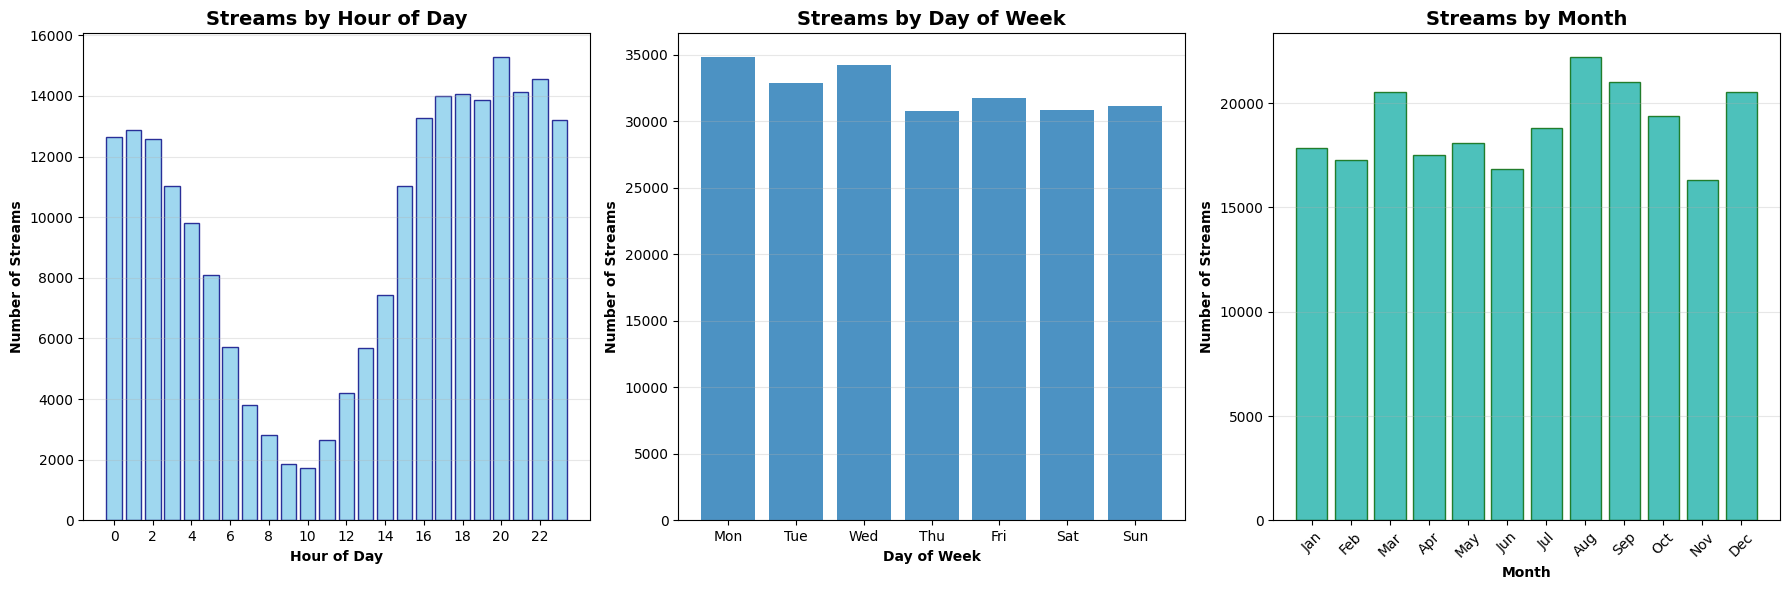

In [79]:
# Define proper ordering
days_ordered = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
month_names_ordered = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']

# Calculate stream counts
hourly_stream_count = spotify_clean['hour'].value_counts().sort_index()
daily_stream_count = spotify_clean['day_of_week'].value_counts().reindex(days_ordered)
monthly_stream_count = spotify_clean['month_name'].value_counts().reindex(month_names_ordered)

# Create the three-panel visualization
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 6))

# 1. HOURLY PATTERNS
bars1 = ax1.bar(hourly_stream_count.index, hourly_stream_count.values, 
                color='skyblue', edgecolor='navy', alpha=0.8)
ax1.set_title('Streams by Hour of Day', fontweight='bold', fontsize=14)
ax1.set_xlabel('Hour of Day', fontweight='bold')
ax1.set_ylabel('Number of Streams', fontweight='bold')
ax1.set_xticks(range(0, 24, 2))
ax1.grid(True, alpha=0.3, axis='y')


# 2. DAILY PATTERNS
bars2 = ax2.bar(range(len(daily_stream_count)), daily_stream_count.values, alpha=0.8)
ax2.set_title('Streams by Day of Week', fontweight='bold', fontsize=14)
ax2.set_xlabel('Day of Week', fontweight='bold')
ax2.set_ylabel('Number of Streams', fontweight='bold')
ax2.set_xticks(range(len(daily_stream_count)))
ax2.set_xticklabels([day[:3] for day in daily_stream_count.index], rotation=0)
ax2.grid(True, alpha=0.3, axis='y')

# 3. MONTHLY PATTERNS
bars3 = ax3.bar(range(len(monthly_stream_count)), monthly_stream_count.values,
                color='lightseagreen', edgecolor='darkgreen', alpha=0.8)
ax3.set_title('Streams by Month', fontweight='bold', fontsize=14)
ax3.set_xlabel('Month', fontweight='bold')
ax3.set_ylabel('Number of Streams', fontweight='bold')
ax3.set_xticks(range(len(monthly_stream_count)))
ax3.set_xticklabels([month[:3] for month in monthly_stream_count.index], rotation=45)
ax3.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()


## Genre Analysis

Now, let's find out what the top ten genres are and plot them.

In [80]:
# Flatten all of the genre lists to get individual genre counts
all_genres = []

for genre_list in spotify_clean['genre_list'].dropna():
    if isinstance(genre_list, list):
        all_genres.extend(genre_list)

# Count the frequency of each genre
genre_counts = pd.Series(all_genres).value_counts()

print(f"Total unique genres: {len(genre_counts)}")
print(f"Total genre instances: {len(all_genres)}")
print(f"Total streams: {len(spotify_clean)}")

print("\nTop 10 genres:")
print(genre_counts.head(10))

Total unique genres: 619
Total genre instances: 388910
Total streams: 226394

Top 10 genres:
Unknown                35361
hip hop                32190
rage rap               15672
underground hip hop    14064
r&b                    12443
rap                    10676
bedroom pop             9217
art pop                 7246
melodic rap             7142
cloud rap               6914
Name: count, dtype: int64


One of the top ten genres is 'Unknown' as many tracks do not have a defined genre in the available metadata or genre tagging.  Aside from that, let's look at the top ten, omitting the 'Unknown' category and compare the plots.

=== TOP 10 GENRES: WITH VS WITHOUT UNKNOWN ===


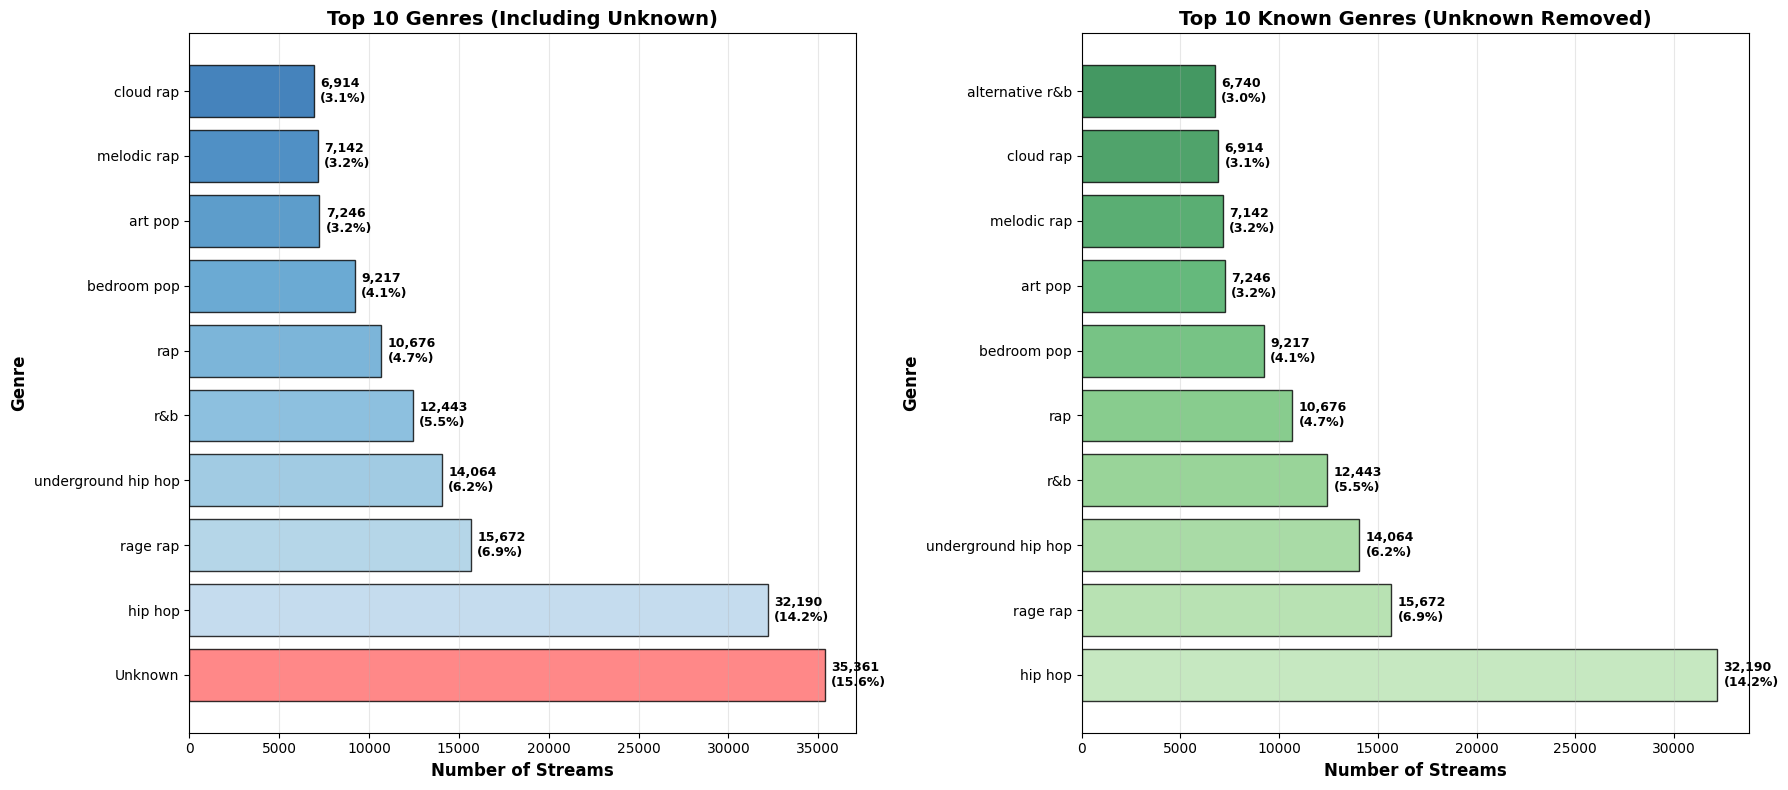

In [81]:
print("=== TOP 10 GENRES: WITH VS WITHOUT UNKNOWN ===")

# Create genre counts without Unknown
genre_counts_no_unknown = genre_counts[genre_counts.index != 'Unknown']

# Get top 10 for both versions
top_10_with_unknown = genre_counts.head(10)
top_10_without_unknown = genre_counts_no_unknown.head(10)

# Create subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))

# Plot 1: With Unknown
bars1 = ax1.barh(range(len(top_10_with_unknown)), top_10_with_unknown.values,
                 color=['#ff6b6b'] + list(plt.cm.Blues(np.linspace(0.3, 0.8, 9))),
                 edgecolor='black', alpha=0.8)
ax1.set_title('Top 10 Genres (Including Unknown)', fontweight='bold', fontsize=14)
ax1.set_xlabel('Number of Streams', fontweight='bold', fontsize=12)
ax1.set_ylabel('Genre', fontweight='bold', fontsize=12)
ax1.set_yticks(range(len(top_10_with_unknown)))
ax1.set_yticklabels(top_10_with_unknown.index)
ax1.grid(True, alpha=0.3, axis='x')

# Add value labels for first plot
for i, bar in enumerate(bars1):
    width = bar.get_width()
    percentage = (width / len(spotify_clean)) * 100
    ax1.text(width + top_10_with_unknown.max() * 0.01, bar.get_y() + bar.get_height()/2.,
             f'{int(width):,}\n({percentage:.1f}%)', 
             ha='left', va='center', fontweight='bold', fontsize=9)

# Plot 2: Without Unknown
bars2 = ax2.barh(range(len(top_10_without_unknown)), top_10_without_unknown.values,
                 color=plt.cm.Greens(np.linspace(0.3, 0.8, len(top_10_without_unknown))),
                 edgecolor='black', alpha=0.8)
ax2.set_title('Top 10 Known Genres (Unknown Removed)', fontweight='bold', fontsize=14)
ax2.set_xlabel('Number of Streams', fontweight='bold', fontsize=12)
ax2.set_ylabel('Genre', fontweight='bold', fontsize=12)
ax2.set_yticks(range(len(top_10_without_unknown)))
ax2.set_yticklabels(top_10_without_unknown.index)
ax2.grid(True, alpha=0.3, axis='x')

# Add value labels for second plot
for i, bar in enumerate(bars2):
    width = bar.get_width()
    percentage = (width / len(spotify_clean)) * 100
    ax2.text(width + top_10_without_unknown.max() * 0.01, bar.get_y() + bar.get_height()/2.,
             f'{int(width):,}\n({percentage:.1f}%)', 
             ha='left', va='center', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.show()

From this we can gather that a lot of my listening is in the realm of hip hop and its many subcategories, with some more alternative genres such as bedroom pop, art pop, and r&b.  Since some tracks have more than one genre assigned, let's look at the distribution of the number of genre tags on each track.

=== DISTRIBUTION OF GENRE TAGS PER TRACK ===
Genre tags per track - Summary Statistics:
count    226394.000000
mean          1.717846
std           1.098411
min           1.000000
25%           1.000000
50%           1.000000
75%           2.000000
max          10.000000
Name: genre_list, dtype: float64


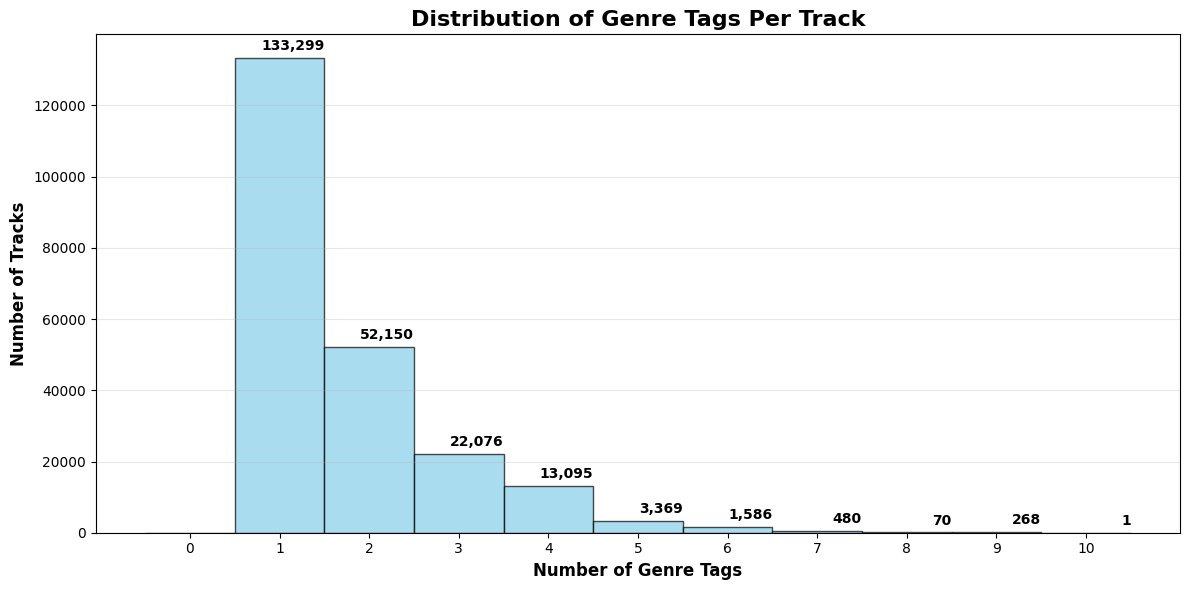

In [82]:
print("=== DISTRIBUTION OF GENRE TAGS PER TRACK ===")

# Calculate number of genres per track
genres_per_track = spotify_clean['genre_list'].apply(
    lambda x: len(x) if isinstance(x, list) else 0
)

print("Genre tags per track - Summary Statistics:")
print(genres_per_track.describe())

# Create the histogram
plt.figure(figsize=(12, 6))

# Plot histogram
n, bins, patches = plt.hist(genres_per_track, 
                           bins=range(0, genres_per_track.max() + 2),
                           edgecolor='black', 
                           alpha=0.7,
                           color='skyblue',
                           align='left')

plt.title('Distribution of Genre Tags Per Track', fontweight='bold', fontsize=16)
plt.xlabel('Number of Genre Tags', fontweight='bold', fontsize=12)
plt.ylabel('Number of Tracks', fontweight='bold', fontsize=12)
plt.xticks(range(0, genres_per_track.max() + 1))
plt.grid(True, alpha=0.3, axis='y')

# Add value labels on top of bars
for i, count in enumerate(n):
    if count > 0:  # Only label non-zero bars
        plt.text(bins[i] + 0.5, count + max(n) * 0.01, 
                f'{int(count):,}', 
                ha='right', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

We can see that the distribution of genre tags is skewed right, with most of the tracks having just one genre tag.

## Listening Habit Analysis

I now want to briefly analyze listening habits in terms of the amount of time I spend listening to music at a given time.  Below I will plot the amount of time I spend listening over time for the entire span of the dataset's time.

=== LISTENING TIME OVER DATASET TIMESPAN ===


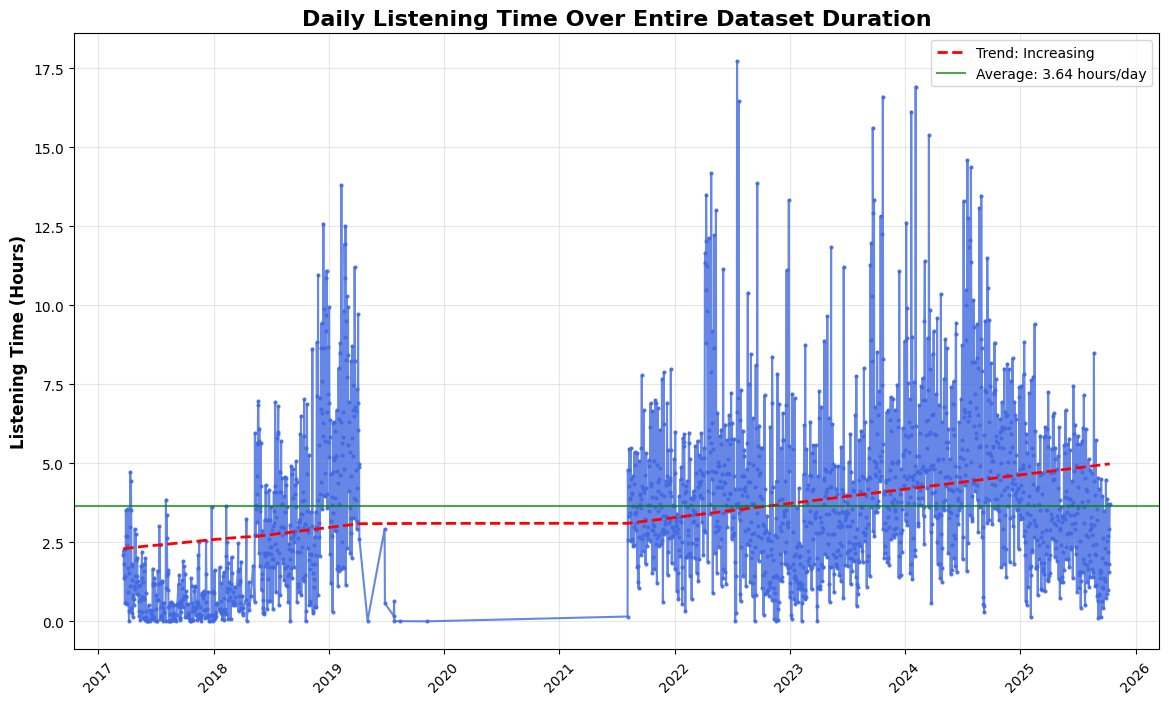

In [83]:
print("=== LISTENING TIME OVER DATASET TIMESPAN ===")

# Method 1: Group by date directly (recommended)
daily_listening = spotify_clean.groupby(spotify_clean['ts'].dt.date).agg({
    'minutes_played': 'sum',
    'ts': 'count'
}).rename(columns={'minutes_played': 'total_minutes', 'ts': 'stream_count'})

daily_listening['total_hours'] = daily_listening['total_minutes'] / 60

# Ensure the index is proper datetime for plotting
daily_listening.index = pd.to_datetime(daily_listening.index)

# Create the main timeline plot
plt.figure(figsize=(14, 8))

# Daily listening hours over time
plt.plot(daily_listening.index, daily_listening['total_hours'], 
         linewidth=1.5, alpha=0.8, color='royalblue', marker='o', markersize=2)
plt.title('Daily Listening Time Over Entire Dataset Duration', fontweight='bold', fontsize=16)
plt.ylabel('Listening Time (Hours)', fontweight='bold', fontsize=12)
plt.grid(True, alpha=0.3)

# Add trend line
x = np.arange(len(daily_listening))
z = np.polyfit(x, daily_listening['total_hours'], 1)
trend_line = np.poly1d(z)
plt.plot(daily_listening.index, trend_line(x), 'r--', linewidth=2, 
         label=f'Trend: {"Increasing" if z[0] > 0 else "Decreasing"}')

# Add average line
avg_hours = daily_listening['total_hours'].mean()
plt.axhline(y=avg_hours, color='green', linestyle='-', alpha=0.7, 
           label=f'Average: {avg_hours:.2f} hours/day')

plt.legend()
plt.xticks(rotation=45)
plt.show();

From this we can see that there has been an increase in the amount of time I've spent listening to music over the years, which makes sense to me.  However, from 2020 to mid 2021 we see that there is no listening happening.  This can be explained by the fact that I had been using Spotify (Free Tier) from 2017 to 2020, but in 2020, my parents purchased a family plan for Apple Music, so I rarely streamed music on Spotify.  In mid 2021, my parents decided to make the switch and get a Spotify Family Plan (Premium Tier), which reignited the listening activity on my account after lying dormant for almost two years.  Knowing the context of my dataset (as it is data relating to myself) helps me to better interpret what is happening in the visualization.  However, this visualization is quite cluttered, so let's separate the lines out for each year and plot them in different colors over the course of one year to see differences in listening activity over the years on a more granular scale.

=== YEAR-OVER-YEAR LISTENING PATTERNS ===


Years in dataset: [2017, 2018, 2019, 2021, 2022, 2023, 2024, 2025]


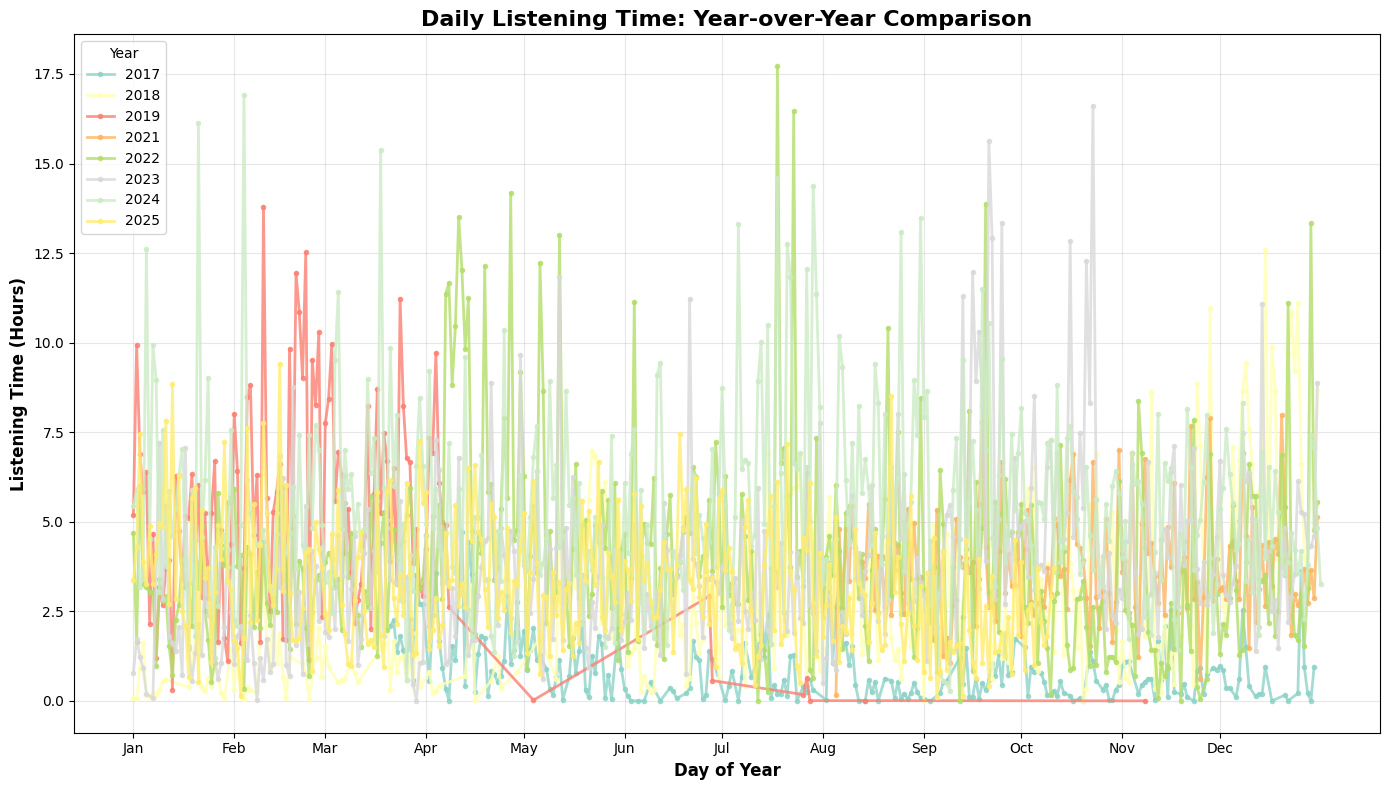

In [84]:
print("=== YEAR-OVER-YEAR LISTENING PATTERNS ===")

# Extract year and day-of-year from timestamp
spotify_clean['year'] = spotify_clean['ts'].dt.year
spotify_clean['day_of_year'] = spotify_clean['ts'].dt.dayofyear

# Calculate daily listening time by year
daily_by_year = spotify_clean.groupby(['year', spotify_clean['ts'].dt.date]).agg({
    'minutes_played': 'sum'
}).reset_index()

daily_by_year['total_hours'] = daily_by_year['minutes_played'] / 60
daily_by_year['date'] = pd.to_datetime(daily_by_year['ts'])
daily_by_year['day_of_year'] = daily_by_year['date'].dt.dayofyear

# Get unique years in the dataset
years = sorted(daily_by_year['year'].unique())
print(f"Years in dataset: {years}")

# Create the comparative plot
plt.figure(figsize=(14, 8))

# Color palette for different years
colors = plt.cm.Set3(np.linspace(0, 1, len(years)))

for i, year in enumerate(years):
    year_data = daily_by_year[daily_by_year['year'] == year]
    
    # Group by day of year to handle multiple entries per day
    yearly_daily = year_data.groupby('day_of_year')['total_hours'].sum().reset_index()
    
    plt.plot(yearly_daily['day_of_year'], yearly_daily['total_hours'],
             label=f'{year}', color=colors[i], linewidth=2, alpha=0.8,
             marker='o', markersize=3)

plt.title('Daily Listening Time: Year-over-Year Comparison', fontweight='bold', fontsize=16)
plt.xlabel('Day of Year', fontweight='bold', fontsize=12)
plt.ylabel('Listening Time (Hours)', fontweight='bold', fontsize=12)
plt.legend(title='Year', fontsize=10)
plt.grid(True, alpha=0.3)

# Set x-axis to show months instead of day numbers
month_positions = [1, 32, 60, 91, 121, 152, 182, 213, 244, 274, 305, 335]
month_labels = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
                'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
plt.xticks(month_positions, month_labels)

plt.tight_layout()
plt.show();

It appears that 2022 is the most prominent year for listening duration over time, and 2017 seems to reside on the lower end of the listening duration in comparison to other years.  This may be because I was on the free tier of Spotify at the time, so I couldn't choose what songs I wanted to listen to, I could only shuffle.  This may have led to shorter listening sessions because I didn't have full control over what I was listening to.

## Behavioral Clustering

Now, I will try to use k-means clustering to find some natural groupings within my dataset given the hour of the day of the stream, the length of the stream (minutes_played), and the day of the week.

In [85]:
print("="*70)
print("FAST BEHAVIORAL CLUSTERING - k=4")
print("="*70)

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("\n🎯 STEP 1: QUICK BEHAVIORAL CLUSTERING")

# Use fixed optimal k = 4
optimal_k = 4
print(f"Using optimal k = {optimal_k} for behavioral clustering")

# Create essential behavioral features
behavior_features = spotify_clean[['hour', 'minutes_played', 'day_of_week_num']].copy()

print(f"Clustering {len(spotify_clean):,} records...")

# Standardize and cluster
scaler = StandardScaler()
features_scaled = scaler.fit_transform(behavior_features)

kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
spotify_clean['behavior_cluster'] = kmeans.fit_predict(features_scaled)

print("✅ Clustering completed!")

print("\n🎯 STEP 2: CLUSTER PROFILES ANALYSIS")

# Group by behavior_cluster from spotify_clean, not behavior_features
cluster_profiles = spotify_clean.groupby('behavior_cluster').agg({
    'hour': 'mean',
    'minutes_played': ['mean', 'std'],
    'day_of_week_num': 'mean',
    'ts': 'count'
}).round(2)

cluster_profiles.columns = ['avg_hour', 'avg_minutes', 'std_minutes', 'avg_weekday', 'cluster_size']
cluster_profiles['size_pct'] = (cluster_profiles['cluster_size'] / len(spotify_clean)) * 100

# Add genre diversity separately
spotify_clean['genre_diversity'] = spotify_clean['genre_list'].apply(
    lambda x: len(x) if isinstance(x, list) else 0
)
genre_diversity_by_cluster = spotify_clean.groupby('behavior_cluster')['genre_diversity'].mean().round(2)
cluster_profiles['avg_genre_diversity'] = genre_diversity_by_cluster

print("\n📊 BEHAVIORAL CLUSTER PROFILES:")
print(cluster_profiles)

print("\n🎯 STEP 3: CLUSTER INTERPRETATION")

print("\n🧩 BEHAVIORAL CLUSTER INTERPRETATIONS:")
for cluster_id in range(optimal_k):
    cluster_data = spotify_clean[spotify_clean['behavior_cluster'] == cluster_id]
    size_pct = (len(cluster_data) / len(spotify_clean)) * 100
    
    # Key metrics
    avg_hour = cluster_data['hour'].mean()
    avg_duration = cluster_data['minutes_played'].mean()
    avg_genre_diversity = cluster_data['genre_diversity'].mean()
    weekend_ratio = (cluster_data['day_of_week_num'] >= 5).mean()
    
    # Create interpretation
    if avg_hour < 12:
        time_desc = "🌅 Morning"
    elif avg_hour < 17:
        time_desc = "🌞 Afternoon" 
    else:
        time_desc = "🌙 Evening"
        
    if avg_duration < 1:
        duration_desc = "Quick skips"
    elif avg_duration < 3:
        duration_desc = "Casual listening"
    else:
        duration_desc = "Deep engagement"
        
    if avg_genre_diversity < 2:
        genre_desc = "Focused tastes"
    elif avg_genre_diversity < 4:
        genre_desc = "Varied interests"
    else:
        genre_desc = "Extremely diverse"
    
    print(f"\n📍 CLUSTER {cluster_id} ({size_pct:.1f}% of streams):")
    print(f"   ⏰ {time_desc} listener ({avg_hour:.1f}:00 avg)")
    print(f"   🎵 {duration_desc} ({avg_duration:.1f} min avg)")
    print(f"   🎶 {genre_desc} ({avg_genre_diversity:.1f} genres/track)")
    print(f"   📅 Weekend ratio: {weekend_ratio:.1%}")

print("\n🎯 STEP 4: GENRE PREFERENCES BY CLUSTER (EXCLUDING UNKNOWN)")

print("\n🎵 TOP GENRE PREFERENCES BY CLUSTER (KNOWN GENRES ONLY):")
for cluster_id in range(optimal_k):
    cluster_data = spotify_clean[spotify_clean['behavior_cluster'] == cluster_id]
    
    # Get top genres for this cluster, excluding Unknown
    cluster_genres = []
    for genre_list in cluster_data['genre_list'].dropna():
        # Filter out 'Unknown' from each track's genre list
        known_genres = [genre for genre in genre_list if genre != 'Unknown']
        cluster_genres.extend(known_genres)
    
    top_cluster_genres = pd.Series(cluster_genres).value_counts().head(3)
    
    print(f"\n📍 Cluster {cluster_id}:")
    if len(top_cluster_genres) > 0:
        for genre, count in top_cluster_genres.items():
            percentage = (count / len(cluster_data)) * 100
            print(f"   • {genre}: {percentage:.1f}% of cluster streams")
    else:
        print(f"   • No known genres in this cluster")

print("\n🎯 STEP 5: CALCULATING SUMMARY STATISTICS")

# Calculate all required statistics for the final summary
total_streams = len(spotify_clean)
avg_session_minutes = spotify_clean['minutes_played'].mean()
skip_rate = (spotify_clean['minutes_played'] < 0.5).mean() * 100
peak_hour = spotify_clean['hour'].value_counts().idxmax()
avg_genres_per_track = spotify_clean['genre_diversity'].mean()

# Genre stats
top_genre_name = genre_counts_no_unknown.index[0]
genre_concentration = (genre_counts_no_unknown.head(5).sum() / total_streams) * 100

# Cluster stats
cluster_size_range = f"{cluster_profiles['size_pct'].min():.1f}% to {cluster_profiles['size_pct'].max():.1f}%"

print("✅ All summary statistics calculated!")

# --- FINAL EDA SUMMARY ---
print("\n" + "="*70)
print("EDA COMPREHENSIVE SUMMARY")
print("="*70)

print(f"\n📊 DATA OVERVIEW:")
print(f"   • Total streams analyzed: {total_streams:,}")
print(f"   • Time period: {spotify_clean['ts'].min().strftime('%Y-%m-%d')} to {spotify_clean['ts'].max().strftime('%Y-%m-%d')}")
print(f"   • Unique genres: {len(genre_counts):,}")
print(f"   • Behavioral clusters identified: {optimal_k}")

print(f"\n🎵 MUSICAL PREFERENCES (EXCLUDING UNKNOWN):")
print(f"   • Top genre: '{top_genre_name}'")
print(f"   • Genre concentration: Top 5 = {genre_concentration:.1f}%")
print(f"   • Average genres per track: {avg_genres_per_track:.1f}")

print(f"\n⏰ LISTENING HABITS:")
print(f"   • Average session: {avg_session_minutes:.2f} minutes")
print(f"   • Skip rate (<30s): {skip_rate:.1f}%")
print(f"   • Peak listening hour: {peak_hour:02d}:00")

print(f"\n🔍 BEHAVIORAL INSIGHTS:")
print(f"   • {optimal_k} distinct listening patterns identified")
print(f"   • Cluster sizes range from {cluster_size_range}")
print(f"   • Listening contexts vary from quick skips to deep engagement")

print(f"\n🎧 CLUSTER BREAKDOWN:")
for cluster_id in range(optimal_k):
    cluster_data = spotify_clean[spotify_clean['behavior_cluster'] == cluster_id]
    size_pct = (len(cluster_data) / len(spotify_clean)) * 100
    avg_hour = cluster_data['hour'].mean()
    avg_duration = cluster_data['minutes_played'].mean()
    weekend_ratio = (cluster_data['day_of_week_num'] >= 5).mean()

    if avg_hour < 12:
        time_desc = "Morning"
    elif avg_hour < 17:
        time_desc = "Afternoon"
    else:
        time_desc = "Evening"

    if avg_duration < 1:
        duration_desc = "quick skips"
    elif avg_duration < 3:
        duration_desc = "casual listening"
    else:
        duration_desc = "deep engagement"

    if weekend_ratio < 0.1:
        day_desc = "weekday-only"
    elif weekend_ratio > 0.4:
        day_desc = "mixed week"
    else:
        day_desc = "weekday-leaning"

    print(f"   • Cluster {cluster_id} ({size_pct:.1f}%): {time_desc} {duration_desc} ({day_desc})")

print(f"\n🎯 READY FOR INFERENCE:")
print("   The behavioral clusters create natural groupings for hypothesis testing")
print("   in Part 3. Each cluster represents a distinct listening context that")
print("   can be analyzed for genre preferences, temporal patterns, and evolution over time.")

print("\n" + "="*70)

FAST BEHAVIORAL CLUSTERING - k=4

🎯 STEP 1: QUICK BEHAVIORAL CLUSTERING
Using optimal k = 4 for behavioral clustering
Clustering 226,394 records...
✅ Clustering completed!

🎯 STEP 2: CLUSTER PROFILES ANALYSIS

📊 BEHAVIORAL CLUSTER PROFILES:
                  avg_hour  avg_minutes  std_minutes  avg_weekday  \
behavior_cluster                                                    
0                    18.23         2.03         1.80         4.53   
1                    17.81         2.03         1.80         0.97   
2                     3.03         2.13         2.03         2.99   
3                    11.47       410.15        31.07         3.06   

                  cluster_size   size_pct  avg_genre_diversity  
behavior_cluster                                                
0                        79016  34.901985                 1.71  
1                        67621  29.868724                 1.73  
2                        79740  35.221781                 1.71  
3                  

## Summary

From what I've explored, we have 226,394 streaming records in our dataset.  After cleaning the data and adding key features such as temporal features and play duration metrics, I was able to analyze some of the features in the dataset.  In terms of temporal patterns, it seems that the majority of music that I listen to is consumed during the early hours and late hours of the day, with a significant decrease in streams in the middle of the day.  Analyzing genre allowed me to identify the top genres, consisting of a lot of 'Unknown' values.  When the 'Unknown' genres were excluded, a lot of my listening was dominated by hip-hop and its various subgenres.  Analyzing listening duration allowed me to understand the lifecycle of my account and my family's transition to Apple Music, as well as our return to Spotify.  This analysis also revealed 2022 to be the most active year for listening for me.  Finally, I used k-means clustering to try to find some natural groupings in the data based on my listening behavior.

# Inference

## Questions and Hypotheses

To start the inference process, I need to come up with a question to ask about the data, and a hypothesis to correspond to this question.

**Question:** Does genre preference vary between weekdays and the weekend?

**Null Hypothesis:** Genre preference does not differ depending on the time of week (weekday or weekend).

**Alternative Hypothesis:** Genre preference leans more toward hip hop and ambient music during the week, whereas more leisure-based genres like rock and pop dominate during the weekend.

**Reasoning:** I want to explore this question because I am interested in how the differences in my daily routine between the weekdays and the weekend may affect my genre consumption during these two distinct times of the week.  I suspect that since I am almost always listening to music when I am doing school assignments (lots of electronic/ambient music) and working out (lots of hip hop), the genre preferences on the weekdays may lean more towards those genres, while on the weekend I have more leisure time to listen to whatever I please, not just music to help me focus on a given task.

## Statistical Models

To answer this question, I want to use a two-proportion z-test to compare the distributions of genres on the weekdays and weekends.  To start, lets start grouping the counts of genre instances.

In [86]:
# Process the genre_list column to get genre counts
print("=== PROCESSING GENRE LISTS ===")

# First, let's see what the genre_list looks like
print("Sample of genre_list column:")
print(spotify_clean['genre_list'].head(10))

print("\n=== EXPLODING GENRE LISTS ===")

# Explode the lists so each genre gets its own row
exploded_genres = spotify_clean.explode('genre_list')

# Clean up the genres (remove whitespace, handle NaN values)
exploded_genres['genre_clean'] = exploded_genres['genre_list'].str.strip().str.lower()

# Get overall genre frequency
print("\nTop 20 most frequent individual genres:")
top_genres = exploded_genres['genre_clean'].value_counts().head(20)
print(top_genres)


=== PROCESSING GENRE LISTS ===
Sample of genre_list column:
63588                                            [Unknown]
63589                                            [lullaby]
63590                         [progressive rock, art rock]
63591                         [progressive rock, art rock]
63592                                            [hip hop]
63593                         [progressive rock, art rock]
63594    [new york drill, drill, sexy drill, brooklyn d...
63595                         [progressive rock, art rock]
63596                         [progressive rock, art rock]
63597                         [progressive rock, art rock]
Name: genre_list, dtype: object

=== EXPLODING GENRE LISTS ===

Top 20 most frequent individual genres:
genre_clean
unknown                 35361
hip hop                 32190
rage rap                15672
underground hip hop     14064
r&b                     12443
rap                     10676
bedroom pop              9217
art pop                 

We can see that the top genre is 'Unknown', as many Spotify tracks lack adequate genre metadata.  Let's exclude the 'Unknown' tracks for a more meaningful analysis.

In [87]:
# Exclude Unknown genres for cleaner analysis
print("=== EXCLUDING UNKNOWN GENRES ===")

# Filter out Unknown genres from the exploded data
exploded_genres_clean = exploded_genres[exploded_genres['genre_clean'] != 'unknown']

print(f"Original exploded rows: {len(exploded_genres)}")
print(f"After removing 'unknown': {len(exploded_genres_clean)}")
print(f"Removed {len(exploded_genres) - len(exploded_genres_clean):,} 'unknown' genre entries")

# Get updated top genres without Unknown
print("\nTop 20 most frequent individual genres (excluding Unknown):")
top_genres_clean = exploded_genres_clean['genre_clean'].value_counts().head(20)
print(top_genres_clean)

=== EXCLUDING UNKNOWN GENRES ===
Original exploded rows: 388910
After removing 'unknown': 353549
Removed 35,361 'unknown' genre entries

Top 20 most frequent individual genres (excluding Unknown):
genre_clean
hip hop                 32190
rage rap                15672
underground hip hop     14064
r&b                     12443
rap                     10676
bedroom pop              9217
art pop                  7246
melodic rap              7142
cloud rap                6914
alternative r&b          6740
jazz                     6489
experimental hip hop     5569
electronic               5390
hard bop                 4644
avant-garde              4614
alternative              4501
free jazz                4372
alternative hip hop      4107
soul                     4097
jazz rap                 4044
Name: count, dtype: int64


To perform our two-proportion z-test on the genre pool we have (excluding unknown genres), we must first clean the genres to focus on the top 20 genres.

In [88]:
print("\n=== GENRE PROPORTION ANALYSIS: WEEKDAY VS WEEKEND ===")


# Extract just the genre names from the Series index
top_genres_list = top_genres_clean.index.tolist()
print("Top genres list:", top_genres_list[:20])  # Show first 20

# Focus on top genres to avoid sparse data
filtered_genres_clean = exploded_genres_clean[
    exploded_genres_clean['genre_clean'].isin(top_genres_list)
]

print(f"Rows after filtering: {len(filtered_genres_clean)}")


=== GENRE PROPORTION ANALYSIS: WEEKDAY VS WEEKEND ===
Top genres list: ['hip hop', 'rage rap', 'underground hip hop', 'r&b', 'rap', 'bedroom pop', 'art pop', 'melodic rap', 'cloud rap', 'alternative r&b', 'jazz', 'experimental hip hop', 'electronic', 'hard bop', 'avant-garde', 'alternative', 'free jazz', 'alternative hip hop', 'soul', 'jazz rap']
Rows after filtering: 170131


Now, we can perform the two-proportion z-test with the genres we have chosen (top 20).

In [89]:
# Z-tests using the filtered_genres_clean data
print("=== Z-TESTS USING FILTERED GENRES CLEAN ===")

# Let's first check what's in filtered_genres_clean
print(f"Shape of filtered_genres_clean: {filtered_genres_clean.shape}")
print(f"Number of unique genres in filtered data: {filtered_genres_clean['genre_clean'].nunique()}")
print(f"Genres in filtered data: {filtered_genres_clean['genre_clean'].unique()}")

# Get the actual genres from the filtered data
genres_in_filtered = filtered_genres_clean['genre_clean'].value_counts().index

# Perform Z-tests on the filtered data
print("\nPerforming Z-tests for genres in filtered data...")
print("-" * 80)

# Store results
ztest_results_filtered = []

for genre in genres_in_filtered:
    # Get counts for this genre from filtered data
    genre_data = filtered_genres_clean[filtered_genres_clean['genre_clean'] == genre]
    
    # Counts for weekdays and weekends
    weekday_count = len(genre_data[genre_data['is_weekend'] == False])
    weekend_count = len(genre_data[genre_data['is_weekend'] == True])
    
    # Total counts for weekdays and weekends IN THE FILTERED DATA
    total_weekday_filtered = len(filtered_genres_clean[filtered_genres_clean['is_weekend'] == False])
    total_weekend_filtered = len(filtered_genres_clean[filtered_genres_clean['is_weekend'] == True])
    
    # Perform two-proportion Z-test
    count = np.array([weekday_count, weekend_count])
    nobs = np.array([total_weekday_filtered, total_weekend_filtered])
    
    z_stat, p_value = proportions_ztest(count, nobs, alternative='two-sided')
    
    # Calculate proportions
    weekday_prop = weekday_count / total_weekday_filtered * 100
    weekend_prop = weekend_count / total_weekend_filtered * 100
    prop_diff = weekend_prop - weekday_prop
    
    # Store results
    ztest_results_filtered.append({
        'genre': genre,
        'weekday_count': weekday_count,
        'weekend_count': weekend_count,
        'weekday_prop': weekday_prop,
        'weekend_prop': weekend_prop,
        'prop_diff': prop_diff,
        'z_stat': z_stat,
        'p_value': p_value
    })

# Convert to DataFrame
results_df_filtered = pd.DataFrame(ztest_results_filtered)

# Sort by absolute proportion difference
results_df_filtered['abs_prop_diff'] = results_df_filtered['prop_diff'].abs()
results_df_sorted_filtered = results_df_filtered.sort_values('abs_prop_diff', ascending=False)

print("\n=== Z-TEST RESULTS (Using Filtered Data) ===")
print(f"{'Genre':<25} {'Weekday %':<10} {'Weekend %':<10} {'Difference':<12} {'Z-stat':<10} {'P-value':<10} {'Significant'}")
print("-" * 90)

alpha = 0.05
for _, row in results_df_sorted_filtered.iterrows():
    significant = "YES" if row['p_value'] < alpha else "no"
    weekday_str = f"{row['weekday_prop']:.2f}%"
    weekend_str = f"{row['weekend_prop']:.2f}%"
    diff_str = f"{row['prop_diff']:+.2f}%"
    
    print(f"{row['genre']:<25} {weekday_str:<10} {weekend_str:<10} {diff_str:<12} {row['z_stat']:>7.2f} {row['p_value']:>9.4f}   {significant}")

# Summary statistics for filtered data
print(f"\n=== SUMMARY (Filtered Data) ===")
significant_results_filtered = results_df_filtered[results_df_filtered['p_value'] < alpha]
print(f"Genres with statistically significant differences: {len(significant_results_filtered)} out of {len(results_df_filtered)}")
print(f"Total streams in filtered data: {len(filtered_genres_clean):,}")
print(f"Weekday streams: {total_weekday_filtered:,} ({total_weekday_filtered/len(filtered_genres_clean)*100:.1f}%)")
print(f"Weekend streams: {total_weekend_filtered:,} ({total_weekend_filtered/len(filtered_genres_clean)*100:.1f}%)")

if len(significant_results_filtered) > 0:
    print("\nSignificantly different genres:")
    for _, row in significant_results_filtered.sort_values('prop_diff', ascending=False).iterrows():
        direction = "more on WEEKENDS" if row['prop_diff'] > 0 else "more on WEEKDAYS"
        print(f"• {row['genre']}: {abs(row['prop_diff']):.2f}% {direction} (p = {row['p_value']:.4f})")

=== Z-TESTS USING FILTERED GENRES CLEAN ===
Shape of filtered_genres_clean: (170131, 32)
Number of unique genres in filtered data: 20
Genres in filtered data: ['hip hop' 'art pop' 'rap' 'electronic' 'jazz' 'jazz rap' 'melodic rap'
 'alternative hip hop' 'r&b' 'experimental hip hop' 'cloud rap'
 'underground hip hop' 'alternative r&b' 'rage rap' 'bedroom pop'
 'alternative' 'free jazz' 'avant-garde' 'hard bop' 'soul']

Performing Z-tests for genres in filtered data...
--------------------------------------------------------------------------------

=== Z-TEST RESULTS (Using Filtered Data) ===
Genre                     Weekday %  Weekend %  Difference   Z-stat     P-value    Significant
------------------------------------------------------------------------------------------
underground hip hop       8.57%      7.46%      -1.11%          7.40    0.0000   YES
bedroom pop               5.14%      6.16%      +1.02%         -8.25    0.0000   YES
r&b                       7.18%      7.68%   

## Evaluate Uncertainty

Now, we need to intepret our results and evaluate how certain (or uncertain) we are about these results.

In [90]:
print("=== UNCERTAINTY EVALUATION: CONFIDENCE INTERVALS & EFFECT SIZES ===")
print("=" * 80)

# 1. CONFIDENCE INTERVALS FOR PROPORTION DIFFERENCES
print("\n1. 95% CONFIDENCE INTERVALS FOR PROPORTION DIFFERENCES")
print("-" * 70)

def proportion_difference_ci(p1, n1, p2, n2, alpha=0.05):
    """Calculate confidence interval for difference between two proportions"""
    p1_prop = p1 / 100
    p2_prop = p2 / 100
    
    se = np.sqrt((p1_prop * (1 - p1_prop) / n1) + (p2_prop * (1 - p2_prop) / n2))
    z = stats.norm.ppf(1 - alpha/2)
    
    diff_prop = p2_prop - p1_prop
    ci_lower = (diff_prop - z * se) * 100
    ci_upper = (diff_prop + z * se) * 100
    
    return ci_lower, ci_upper, se * 100

print(f"{'Genre':<25} {'Difference':<10} {'95% CI':<25} {'CI Width':<12} {'Contains 0?'}")
print("-" * 85)

total_weekday = len(filtered_genres_clean[filtered_genres_clean['is_weekend'] == False])
total_weekend = len(filtered_genres_clean[filtered_genres_clean['is_weekend'] == True])

for _, row in results_df_sorted_filtered.iterrows():
    ci_lower, ci_upper, std_error = proportion_difference_ci(
        row['weekday_prop'], total_weekday,
        row['weekend_prop'], total_weekend
    )
    
    ci_width = ci_upper - ci_lower
    ci_str = f"[{ci_lower:+.3f}%, {ci_upper:+.3f}%]"
    diff_str = f"{row['prop_diff']:+.2f}%"
    contains_zero = "NO" if (ci_lower > 0 or ci_upper < 0) else "YES"
    
    print(f"{row['genre']:<25} {diff_str:<10} {ci_str:<25} {ci_width:.3f}%       {contains_zero}")

# 2. EFFECT SIZE ANALYSIS
print(f"\n2. EFFECT SIZE ANALYSIS (Cohen's h)")
print("-" * 70)

def cohens_h(p1, p2):
    """Calculate Cohen's h for effect size of proportion difference"""
    p1_prop = p1 / 100
    p2_prop = p2 / 100
    return 2 * np.arcsin(np.sqrt(p2_prop)) - 2 * np.arcsin(np.sqrt(p1_prop))

print(f"{'Genre':<25} {'Difference':<10} {'Cohen\'s h':<10} {'Effect Size':<15} {'Interpretation'}")
print("-" * 85)

effect_size_categories = {
    (0, 0.2): "Very Small",
    (0.2, 0.5): "Small", 
    (0.5, 0.8): "Medium",
    (0.8, float('inf')): "Large"
}

for _, row in results_df_sorted_filtered.iterrows():
    h = cohens_h(row['weekday_prop'], row['weekend_prop'])
    abs_h = abs(h)
    
    # Classify effect size
    effect_size = "Very Small"
    for range_, category in effect_size_categories.items():
        if range_[0] <= abs_h < range_[1]:
            effect_size = category
            break
    
    # Interpretation based on magnitude
    if abs_h < 0.1:
        interpretation = "Negligible"
    elif abs_h < 0.2:
        interpretation = "Very small but detectable"
    elif abs_h < 0.3:
        interpretation = "Small but meaningful"
    elif abs_h < 0.5:
        interpretation = "Moderate"
    else:
        interpretation = "Substantial"
    
    diff_str = f"{row['prop_diff']:+.2f}%"
    print(f"{row['genre']:<25} {diff_str:<10} {abs_h:>7.3f}    {effect_size:<15} {interpretation}")

# 3. COMBINED UNCERTAINTY ASSESSMENT
print(f"\n3. COMBINED UNCERTAINTY ASSESSMENT")
print("-" * 70)

print("🔍 HIGH CONFIDENCE FINDINGS (CI excludes 0 AND effect size > 0.1):")
high_confidence = []
for _, row in results_df_sorted_filtered.iterrows():
    ci_lower, ci_upper, _ = proportion_difference_ci(
        row['weekday_prop'], total_weekday,
        row['weekend_prop'], total_weekend
    )
    h = abs(cohens_h(row['weekday_prop'], row['weekend_prop']))
    
    if (ci_lower > 0 or ci_upper < 0) and h > 0.1:
        high_confidence.append((row['genre'], row['prop_diff'], h))

for genre, diff, h in sorted(high_confidence, key=lambda x: abs(x[1]), reverse=True):
    direction = "WEEKENDS" if diff > 0 else "WEEKDAYS"
    print(f"  • {genre}: {abs(diff):.2f}% more on {direction} (h = {h:.3f})")

print(f"\n⚠️  UNCERTAIN FINDINGS (CI includes 0 OR effect size < 0.05):")
uncertain = []
for _, row in results_df_sorted_filtered.iterrows():
    ci_lower, ci_upper, _ = proportion_difference_ci(
        row['weekday_prop'], total_weekday,
        row['weekend_prop'], total_weekend
    )
    h = abs(cohens_h(row['weekday_prop'], row['weekend_prop']))
    
    if (ci_lower <= 0 <= ci_upper) or h < 0.05:
        uncertain.append((row['genre'], row['prop_diff'], h, ci_lower <= 0 <= ci_upper))

for genre, diff, h, ci_includes_zero in sorted(uncertain, key=lambda x: abs(x[1])):
    direction = "WEEKENDS" if diff > 0 else "WEEKDAYS"
    reason = "CI includes 0" if ci_includes_zero else "Very small effect"
    print(f"  • {genre}: {abs(diff):.2f}% more on {direction} (h = {h:.3f}) - {reason}")

# 4. PRECISION ANALYSIS
print(f"\n4. PRECISION ANALYSIS")
print("-" * 70)

# Calculate average confidence interval width
ci_widths = []
for _, row in results_df_sorted_filtered.iterrows():
    ci_lower, ci_upper, _ = proportion_difference_ci(
        row['weekday_prop'], total_weekday,
        row['weekend_prop'], total_weekend
    )
    ci_widths.append(ci_upper - ci_lower)

avg_ci_width = np.mean(ci_widths)
min_ci_width = np.min(ci_widths)
max_ci_width = np.max(ci_widths)

print(f"Average 95% CI width: {avg_ci_width:.3f}%")
print(f"Minimum CI width: {min_ci_width:.3f}%")
print(f"Maximum CI width: {max_ci_width:.3f}%")
print(f"\nInterpretation:")
if avg_ci_width < 0.5:
    print("  • High precision - narrow confidence intervals")
elif avg_ci_width < 1.0:
    print("  • Good precision - reasonably narrow intervals") 
else:
    print("  • Moderate precision - some uncertainty in estimates")

# 5. SUMMARY OF MOST RELIABLE FINDINGS
print(f"\n5. SUMMARY: MOST RELIABLE DAY-TIME GENRE PREFERENCES")
print("-" * 70)

print("🎵 STRONGEST WEEKEND PREFERENCES (high confidence + meaningful effect):")
weekend_strong = []
for _, row in results_df_sorted_filtered[results_df_sorted_filtered['prop_diff'] > 0].iterrows():
    ci_lower, ci_upper, _ = proportion_difference_ci(
        row['weekday_prop'], total_weekday,
        row['weekend_prop'], total_weekend
    )
    h = abs(cohens_h(row['weekday_prop'], row['weekend_prop']))
    
    if ci_lower > 0 and h > 0.1:  # CI excludes 0 and meaningful effect
        weekend_strong.append((row['genre'], row['prop_diff'], h))

for genre, diff, h in sorted(weekend_strong, key=lambda x: x[1], reverse=True):
    print(f"  • {genre}: +{diff:.2f}% on weekends (effect size: {h:.3f})")

print(f"\n🎵 STRONGEST WEEKDAY PREFERENCES (high confidence + meaningful effect):")
weekday_strong = []
for _, row in results_df_sorted_filtered[results_df_sorted_filtered['prop_diff'] < 0].iterrows():
    ci_lower, ci_upper, _ = proportion_difference_ci(
        row['weekday_prop'], total_weekday,
        row['weekend_prop'], total_weekend
    )
    h = abs(cohens_h(row['weekday_prop'], row['weekend_prop']))
    
    if ci_upper < 0 and h > 0.1:  # CI excludes 0 and meaningful effect
        weekday_strong.append((row['genre'], row['prop_diff'], h))

for genre, diff, h in sorted(weekday_strong, key=lambda x: x[1]):
    print(f"  • {genre}: {abs(diff):.2f}% more on weekdays (effect size: {h:.3f})")

print(f"\n📊 OVERALL UNCERTAINTY ASSESSMENT:")
print(f"• {len(high_confidence)} genres show reliable differences (CI excludes 0 + meaningful effect)")
print(f"• {len(uncertain)} genres have uncertain differences")
print(f"• Average precision: ±{avg_ci_width/2:.3f}% margin of error")
print(f"• Most effects are small (Cohen's h < 0.3) but reliably detected due to large sample size")

=== UNCERTAINTY EVALUATION: CONFIDENCE INTERVALS & EFFECT SIZES ===

1. 95% CONFIDENCE INTERVALS FOR PROPORTION DIFFERENCES
----------------------------------------------------------------------
Genre                     Difference 95% CI                    CI Width     Contains 0?
-------------------------------------------------------------------------------------
underground hip hop       -1.11%     [-1.394%, -0.823%]        0.571%       NO
bedroom pop               +1.02%     [+0.766%, +1.268%]        0.502%       NO
r&b                       +0.51%     [+0.227%, +0.791%]        0.564%       NO
experimental hip hop      -0.44%     [-0.619%, -0.251%]        0.368%       NO
hip hop                   +0.42%     [+0.004%, +0.843%]        0.839%       NO
rap                       +0.38%     [+0.121%, +0.646%]        0.524%       NO
art pop                   -0.36%     [-0.573%, -0.150%]        0.423%       NO
alternative               +0.34%     [+0.169%, +0.521%]        0.352%       NO

The uncertainty analysis shows us a clear distinction between statistical and practical significance. While 14 of 20 genres show statistically reliable differences between weekdays and weekends (confidence intervals exclude zero), all effect sizes are negligible (Cohen's h < 0.05). The narrow confidence intervals (±0.22% average margin of error) provide high precision, solidifying that these small differences are real but practically meaningless. This indicates that although my genre preferences show minute statistical variations by day type (weekday or weekend), these differences are too small to represent meaningful changes in listening behavior. The main takeaway is consistency in music taste across different days of the week.

## Consideration of Assumptions
When performing the two-proportion z-tests, there are various assumptions that need to be considered for a valid analysis.

### Independence of Observations
The assumption that each genre stream observation is independent of another is partially true, as streams from the same listening session may be correlated in some way.  

### Sample Size Assumption
For the 170,131 observations that we have in our filtered data, we have to operate under the assumption that np >= 5 and n(1-p) >= 5 for both groups, which is true in this case for the counts of weekday and weekend streams.

### Binomial Distribution Assumption
The z-tests performed also operate under the assumption that each stream is a Bernoulli trial (genre or not genre), where there is a fixed number of trials (total number of streams per day type) and a constant probability of success (genre proportion).

### Random Sampling Assumption
There is an assumption for z-tests that the data represents a random sample from the population, and this is partially violated because the data represents the complete personal listening history for myself.  Having the data correspond to a single user (me) limits population generalization, but the large time span (2017-2025) provides a range of temporal diversity.

## Conclusion

Overall, from this analysis we can conclude that the z-test results are statistically valid and reliable, but the detected differences are too small to be practically meaningful in terms of genre preference behavior changes between weekdays and weekends.  While the analysis has told us that there are significant differences detected in 14 out of 20 genres, with underground hip hop being more dominant on the weekdays (+1.11%) and bedroom pop being more favored on the weekends (+1.02%), these differences are practically insignificant because all effect sizes were negligible (Cohen's h < 0.05).  This tells us that while the patterns are statistically reliable due to the large dataset of 170,131 streams, they represent no meaningful change in genre preference between weekdays and the weekend.  This defies my hypothesis of music taste being dependent on the context of the weekday, yet highlights the overall consistency of my musical taste throughout the week.  It is important to distinguish the statistical significance and practical importance here, because although we found statistically significant results for 14 genres, the effect sizes are so small that in a practical sense, these changes don't mean much.  I've learned that I hold strong in my music taste and choices no matter what time of the week, but the subtle changes align with my suspicions of hip hop being favored during the week and pop and rock genres (like bedroom pop) being slightly more favored on the weekends.

# Prediction

## Identify a Modeling Target

The first step of prediction is to identify the target we want to model.  In this case, I want to try to model whether or not a song is skipped based on other features of the dataset.  Prediction of whether or not a user (myself) will skip a song has a clear business value for music recommendation systems and can help to improve sequencing of curated playlists and listening satisfaction.

## Consideration of Variables and Model Approaches

### Regression or Classification
Given that the target variable is whether or not a song is skipped, this is a binary classification problem (skipped or not skipped).  The target outcome is categorical, so regression would not be appropriate in this case.

### Desirable Characteristics in the Models
I will try to prioritize a model that can handle mixed data types (both numerical and categorical features, as that is what is included in the many features of my dataset).  I will also try to find a model that provides an interpretable result, and can handle class imbalance as skip events are usually much less frequent than non-skip events.  Based on this, I am going to try to fit a Logistic Regression model, and a Random Forest model.

## Approach to Model Fitting and Error Estimation

### Data Split
The dataset will be split for a fair evaluation:

__Test Set__: I will hold out a test set of 20% of the data to be used only once to evaluate the performance of the chosen model.

__Training Set__: The remaining 80% will be used for model development.  I will use k-fold cross-validation to systematically divide data for validation and average the performance across all folds.  This will ensure a more stable estimate of the model's generalization error.

## Data Leakage Audit

Before splitting and fitting, it is important to check for data leakage — features that
would not be available at prediction time, or that directly encode the target variable.

In this dataset, three columns are leaky for predicting `skipped`:

| Column | Why it leaks |
|---|---|
| `ms_played` | Directly records how long the track played. A skipped track will always have a low value. |
| `seconds_played` | Derived from `ms_played` (÷ 1000). Same leakage. |
| `minutes_played` | Derived from `ms_played` (÷ 60,000). Same leakage. |

A model trained with these columns present is not learning *why* someone skips a song —
it is simply learning that skipped streams have low play durations. This gives artificially
high accuracy (99%+) that would not hold in a real-world deployment where the model would
need to predict a skip *before* it happens.

These columns are excluded from the feature set below.

In [91]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                           f1_score, roc_auc_score, confusion_matrix,
                           classification_report, roc_curve)
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)

data = spotify_clean.copy()

# --- LEAKAGE FIX ---
# ms_played, seconds_played, and minutes_played directly encode how long a track
# played, making them a near-perfect proxy for the skip label. They are excluded
# so the model must learn from pre-play features only.
LEAKY_COLS = [
    'ms_played', 'seconds_played', 'minutes_played',  # direct play duration
    'behavior_cluster',  # k-means trained on minutes_played
    'ts',                # raw timestamp
    'reason_end',        # literally records how/why the stream ended
    'reason_start',      # post-play metadata from the prior stream
]
data = data.drop(columns=[c for c in LEAKY_COLS if c in data.columns])
print(f"Dropped leaky columns: {[c for c in LEAKY_COLS if c in spotify_clean.columns]}")

# Define target variable
target_col = 'skipped'
print(f"\nTarget distribution:")
print(data[target_col].value_counts(normalize=True))

# Separate features and target
X = data.drop(columns=[target_col])
y = data[target_col]

# Identify categorical and numerical columns
categorical_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

print(f"\nCategorical features ({len(categorical_cols)}): {categorical_cols}")
print(f"Numerical features ({len(numerical_cols)}): {numerical_cols}")

# Remove features with too many missing values
missing_threshold = 0.3
missing_ratios = X.isnull().sum() / len(X)
cols_to_drop = missing_ratios[missing_ratios > missing_threshold].index.tolist()
if cols_to_drop:
    X = X.drop(columns=cols_to_drop)
    print(f"\nDropped columns with >{missing_threshold*100}% missing values: {cols_to_drop}")
    categorical_cols = [col for col in categorical_cols if col not in cols_to_drop]
    numerical_cols = [col for col in numerical_cols if col not in cols_to_drop]

# Stratified train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\n✅ Train-Test Split Complete:")
print(f"Training set: {X_train.shape} ({(X_train.shape[0]/len(data)*100):.1f}%)")
print(f"Test set: {X_test.shape} ({(X_test.shape[0]/len(data)*100):.1f}%)")
print(f"\nClass distribution in training set:")
print(y_train.value_counts(normalize=True))
print(f"\nClass distribution in test set:")
print(y_test.value_counts(normalize=True))


Dropped leaky columns: ['ms_played', 'seconds_played', 'minutes_played', 'behavior_cluster', 'ts', 'reason_end', 'reason_start']

Target distribution:
skipped
False    0.768037
True     0.231963
Name: proportion, dtype: float64

Categorical features (13): ['platform', 'conn_country', 'ip_addr', 'track_name', 'artist_name', 'album_name', 'spotify_track_uri', 'offline', 'genre', 'genre_method', 'genre_list', 'day_of_week', 'month_name']
Numerical features (2): ['offline_timestamp', 'genre_diversity']

✅ Train-Test Split Complete:
Training set: (181115, 23) (80.0%)
Test set: (45279, 23) (20.0%)

Class distribution in training set:
skipped
False    0.768037
True     0.231963
Name: proportion, dtype: float64

Class distribution in test set:
skipped
False    0.768038
True     0.231962
Name: proportion, dtype: float64


### Evaluation of Multiple Possible Models and Model Selection
Now, we can fit both models and evaluate the fit of both models (Logistic Regression and Random Forest).  First, I will do some conversion of features and bundle the preprocessing of the data to fit the model.

In [92]:
# Convert categorical columns to strings to handle mixed types
print("Converting categorical columns to strings...")
for col in categorical_cols:
    X_train[col] = X_train[col].astype(str)
    X_test[col] = X_test[col].astype(str)
print("✅ Categorical columns converted to strings")

# Preprocessing for numerical data
numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Preprocessing for categorical data
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False, max_categories=10))
])

# Bundle preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_cols),
        ('cat', categorical_transformer, categorical_cols)
    ])

Converting categorical columns to strings...
✅ Categorical columns converted to strings


Next, I will define and store pipelines for each of the models.

In [93]:
# Model 1: Logistic Regression
logreg_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced'))
])

# Simplified parameter grid for Logistic Regression
logreg_params = {
    'classifier__C': [0.1, 1, 10],  
}

# Model 2: Random Forest
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42, class_weight='balanced'))
])

# Simplified parameter grid for Random Forest
rf_params = {
    'classifier__n_estimators': [100, 200],  
    'classifier__max_depth': [10, 20],       
}

# Store models
models = {
    'Logistic Regression': (logreg_pipeline, logreg_params),
    'Random Forest': (rf_pipeline, rf_params)
}

print(f"✅ Defined {len(models)} models for k-fold cross-validation")

✅ Defined 2 models for k-fold cross-validation


Now we can perform k-fold cross-validation with our 5 folds.

In [94]:
# Cross-validation setup (using k=5 folds)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Store cross-validation results
cv_results = {}

for model_name, (pipeline, params) in models.items():
    print(f"\n{'='*50}")
    print(f"Evaluating {model_name} with 5-fold CV")
    print('='*50)
    
    try:
        # Perform grid search with cross-validation
        grid_search = GridSearchCV(
            estimator=pipeline,
            param_grid=params,
            cv=cv,
            scoring='f1',  # Use F1 score due to class imbalance
            n_jobs=1,      # Set to 1 to avoid memory issues
            verbose=0,     # Set to 0 for cleaner output (change to 1 if you want details)
            error_score='raise'
        )
        
        # Fit the model with cross-validation
        print(f"Performing 5-fold cross-validation for {model_name}...")
        grid_search.fit(X_train, y_train)
        
        # Store results
        cv_results[model_name] = {
            'model': grid_search.best_estimator_,
            'best_params': grid_search.best_params_,
            'best_score': grid_search.best_score_,
            'cv_scores': grid_search.cv_results_['mean_test_score'],
            'cv_std': grid_search.cv_results_['std_test_score']
        }
        
        print(f"✅ Best parameters: {grid_search.best_params_}")
        print(f"✅ Best CV F1 score: {grid_search.best_score_:.4f}")
        print(f"✅ CV F1 scores per fold: {grid_search.cv_results_['mean_test_score']}")
        
    except Exception as e:
        print(f"❌ Error during cross-validation: {str(e)[:200]}...")
        print("Trying simple cross-validation without grid search...")
        
        # Fallback: Simple cross-validation with default parameters
        try:
            cv_scores = cross_val_score(pipeline, X_train, y_train, 
                                       cv=cv, scoring='f1', n_jobs=1)
            
            cv_results[model_name] = {
                'model': pipeline,
                'best_params': 'default',
                'best_score': cv_scores.mean(),
                'cv_scores': cv_scores,
                'cv_std': cv_scores.std()
            }
            
            print(f"✅ CV F1 score (default params): {cv_scores.mean():.4f} (±{cv_scores.std():.4f})")
            
        except Exception as e2:
            print(f"❌ Failed even with default parameters: {str(e2)[:200]}...")
            continue

# ===============================
# MODEL SELECTION BASED ON CV RESULTS
# ===============================

print("\n" + "="*60)
print("MODEL SELECTION")
print("="*60)

if not cv_results:
    print("❌ No models were successfully trained. Check data preprocessing.")
else:
    # Compare models and select the best one
    best_model_name = max(cv_results, key=lambda x: cv_results[x]['best_score'])
    best_model = cv_results[best_model_name]['model']
    best_cv_score = cv_results[best_model_name]['best_score']
    
    print(f"✅ SELECTED BEST MODEL: {best_model_name}")
    print(f"   Best CV F1 score: {best_cv_score:.4f}")
    print(f"   Best parameters: {cv_results[best_model_name]['best_params']}")
    
    # Display cross-validation results for all models
    print(f"\n📊 CROSS-VALIDATION RESULTS SUMMARY:")
    for model_name, results in cv_results.items():
        print(f"\n{model_name}:")
        print(f"  Best CV F1: {results['best_score']:.4f}")
        if 'cv_scores' in results and isinstance(results['cv_scores'], np.ndarray):
            # Fixed formatting
            formatted_scores = [f"{s:.4f}" for s in results['cv_scores']]
            print(f"  Fold scores: {formatted_scores}")
            # Get std - handle if it's an array or single value
            cv_std = results.get('cv_std', None)
            if cv_std is None:
                cv_std = results['cv_scores'].std()
            elif isinstance(cv_std, np.ndarray):
                cv_std = cv_std.mean()  # Take mean if it's an array
            
            # Format with proper type handling
            best_score_str = f"{float(results['best_score']):.4f}"
            cv_std_str = f"{float(cv_std):.4f}"
            print(f"  Mean ± Std: {best_score_str} ± {cv_std_str}")


Evaluating Logistic Regression with 5-fold CV
Performing 5-fold cross-validation for Logistic Regression...
✅ Best parameters: {'classifier__C': 10}
✅ Best CV F1 score: 0.5725
✅ CV F1 scores per fold: [0.57208998 0.57248421 0.57251711]

Evaluating Random Forest with 5-fold CV
Performing 5-fold cross-validation for Random Forest...
✅ Best parameters: {'classifier__max_depth': 20, 'classifier__n_estimators': 100}
✅ Best CV F1 score: 0.5791
✅ CV F1 scores per fold: [0.56976668 0.56963399 0.5790854  0.57849114]

MODEL SELECTION
✅ SELECTED BEST MODEL: Random Forest
   Best CV F1 score: 0.5791
   Best parameters: {'classifier__max_depth': 20, 'classifier__n_estimators': 100}

📊 CROSS-VALIDATION RESULTS SUMMARY:

Logistic Regression:
  Best CV F1: 0.5725
  Fold scores: ['0.5721', '0.5725', '0.5725']
  Mean ± Std: 0.5725 ± 0.0014

Random Forest:
  Best CV F1: 0.5791
  Fold scores: ['0.5698', '0.5696', '0.5791', '0.5785']
  Mean ± Std: 0.5791 ± 0.0011


## Evaluation of the Final Model
The Random Forest model seems to have come out on top!  Now we can evaluate how well this model represents our data using the test set we tucked away earlier.

In [95]:
# ===============================
# FINAL MODEL TRAINING AND TEST EVALUATION
# ===============================

print("\n" + "="*60)
print("FINAL MODEL EVALUATION ON TEST SET")
print("="*60)

if 'best_model' in locals():
    # Train the best model on the full training set
    print(f"Training {best_model_name} on full training set...")
    best_model.fit(X_train, y_train)
    
    # Make predictions on test set
    y_pred = best_model.predict(X_test)
    y_pred_proba = best_model.predict_proba(X_test)[:, 1]
    
    # Calculate metrics
    test_accuracy = accuracy_score(y_test, y_pred)
    test_precision = precision_score(y_test, y_pred)
    test_recall = recall_score(y_test, y_pred)
    test_f1 = f1_score(y_test, y_pred)
    test_roc_auc = roc_auc_score(y_test, y_pred_proba)
    
    print("📊 TEST SET PERFORMANCE:")
    print(f"Accuracy:  {test_accuracy:.4f}")
    print(f"Precision: {test_precision:.4f}")
    print(f"Recall:    {test_recall:.4f}")
    print(f"F1 Score:  {test_f1:.4f}")
    print(f"ROC-AUC:   {test_roc_auc:.4f}")
    
    print("\n📋 Classification Report:")
    print(classification_report(y_test, y_pred))


FINAL MODEL EVALUATION ON TEST SET
Training Random Forest on full training set...
📊 TEST SET PERFORMANCE:
Accuracy:  0.6888
Precision: 0.4216
Recall:    0.9192
F1 Score:  0.5781
ROC-AUC:   0.8317

📋 Classification Report:
              precision    recall  f1-score   support

       False       0.96      0.62      0.75     34776
        True       0.42      0.92      0.58     10503

    accuracy                           0.69     45279
   macro avg       0.69      0.77      0.67     45279
weighted avg       0.84      0.69      0.71     45279



The Random Forest model is able to predict whether or not a stream was skipped or not somewhat well, but it could be improved on.


VISUALIZATIONS


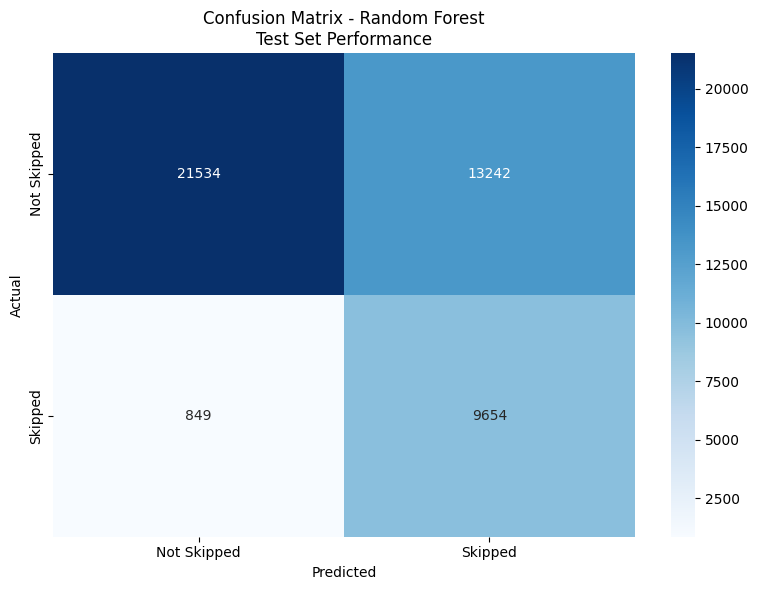

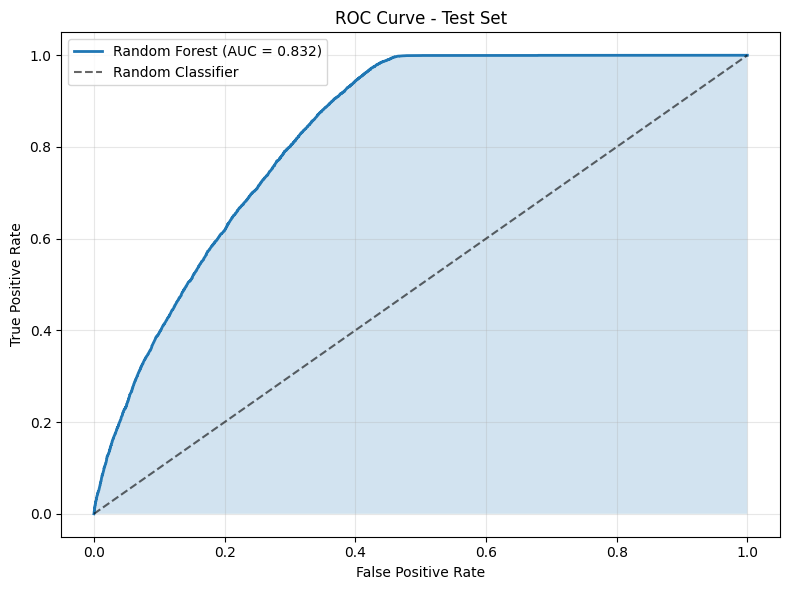

In [96]:
# ===============================
# VISUALIZATIONS
# ===============================
    
print("\n" + "="*60)
print("VISUALIZATIONS")
print("="*60)
    
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
    xticklabels=['Not Skipped', 'Skipped'],
    yticklabels=['Not Skipped', 'Skipped'])
plt.title(f'Confusion Matrix - {best_model_name}\nTest Set Performance')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()
    
# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'{best_model_name} (AUC = {test_roc_auc:.3f})', linewidth=2)
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier', alpha=0.6)
plt.fill_between(fpr, tpr, alpha=0.2)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Test Set')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

The Random Forest model achieves an AUC of 0.83, meaning it does a reasonable job of ranking skipped streams above non-skipped ones — well above the 0.50 baseline of random guessing. The ROC curve reflects this, sitting meaningfully above the diagonal across most threshold values.
The more telling story is in the precision-recall tradeoff. With recall of 0.92, the model catches the vast majority of actual skips — only about 8% slip through undetected. The cost of that high recall is low precision (0.42), meaning roughly half of streams the model flags as skips are actually listens. In practical terms, the model casts a wide net: good at finding skips, but noisy about what it calls one.

## Evaluation of Model Utility

In [97]:
# ===============================
# MODEL UTILITY ANALYSIS
# ===============================
    
print("\n" + "="*60)
print("MODEL UTILITY ANALYSIS")
print("="*60)
    
# Baseline comparison
baseline_accuracy = max(y_test.value_counts(normalize=True))
improvement = test_accuracy - baseline_accuracy
    
print(f"📊 BASELINE COMPARISON:")
print(f"  Baseline (predict all as majority class): {baseline_accuracy:.2%}")
print(f"  Model improvement: {improvement:+.2%}")
    
# Skip prediction insights
print(f"\n🎵 SKIP PREDICTION PERFORMANCE:")
print(f"  Skip catch rate (recall): {test_recall:.2%}")
print(f"  Precision on skips: {test_precision:.2%}")
    
# Business recommendations
print(f"\n💡 BUSINESS RECOMMENDATIONS:")
if test_f1 > 0.7:
    print("  ✅ STRONG MODEL - Ready for production use")
    print("     • Can automatically reorder playlists")
    print("     • Can suggest song removals")
elif test_f1 > 0.5:
    print("  ⚠️ MODERATE MODEL - Use with oversight")
    print("     • Flag high-skip-risk songs for review")
    print("     • Use for A/B testing")
elif test_f1 <= 0.5:
    print("  🔧 MODEL NEEDS IMPROVEMENT")
    print("     • Consider collecting more features")
    print("     • Try different modeling approaches")
    
else:
    print("❌ No model selected. Unable to proceed with test evaluation.")


MODEL UTILITY ANALYSIS
📊 BASELINE COMPARISON:
  Baseline (predict all as majority class): 76.80%
  Model improvement: -7.92%

🎵 SKIP PREDICTION PERFORMANCE:
  Skip catch rate (recall): 91.92%
  Precision on skips: 42.16%

💡 BUSINESS RECOMMENDATIONS:
  ⚠️ MODERATE MODEL - Use with oversight
     • Flag high-skip-risk songs for review
     • Use for A/B testing


At 68.9% accuracy, the model outperforms the majority-class baseline (predicting everything as "not skipped" would yield ~76% accuracy on its own, since skips are the minority class), but the more meaningful measure here is what the model does with the harder problem of identifying actual skips. With F1 of 0.58 on the skip class, this is a genuinely useful signal rather than a trivially easy classification.
The high recall makes this model better suited to some applications than others. For playlist sequencing or skip-risk flagging — where missing a likely skip is worse than over-flagging — the 0.92 recall is an asset. For precision-sensitive use cases, like automatically removing songs from a library, the 0.42 precision would generate too many false positives to be reliable without human review.
Features that would likely improve performance are audio characteristics not present in the listening history export: danceability, tempo, energy, valence, and key are all available via the Spotify Web API and would give the model something to work with beyond contextual signals like time of day and genre.

## Known Limitations

### Data Leakage (resolved)
An earlier version of this model included several features that directly or indirectly encoded the target variable. `ms_played`, `seconds_played`, and `minutes_played` record how long a track played — a near-perfect proxy for skipping by definition. `reason_end` records the mechanism by which a stream ended (e.g. `"fwdbtn"` for forward button), which is the skip event itself. `behavior_cluster` carried leakage indirectly, as the k-means clustering earlier in the notebook was trained using `minutes_played` as a feature. All five columns were removed, bringing AUC from a spurious 1.00 down to 0.83 — a result that reflects genuine signal rather than the model reading its own answer key.

### Class Imbalance
Skips represent roughly 23% of streams in this dataset. The Random Forest was trained with `class_weight='balanced'` to compensate, which drives recall up (0.92) at the cost of precision (0.42). The high recall is useful for skip-flagging applications but means the model produces a significant number of false positives — about half of predicted skips are actually full listens.

### Missing Audio Features
The Spotify extended history export contains no audio characteristics. Features like danceability, tempo, energy, valence, and key — all available via the Spotify Web API — would likely improve precision meaningfully, since the current model can only work from contextual signals (time of day, genre, platform) rather than anything intrinsic to the music itself.

### Single-User Generalization
The dataset covers one Spotify account over eight years. The model captures patterns specific to one listener and should not be expected to generalize to other users without retraining.

### Temporal Leakage
The train/test split is random rather than time-based. Because listening habits evolved considerably over the 2017–2025 span of this dataset, a time-based split — training on pre-2024 data and testing on 2024–2025 — would give a more realistic estimate of how well the model generalizes to future listening behavior.